# Exploratory Data Analysis (EDA)

This notebook performs a comprehensive exploratory analysis on the cleaned Bangalore Rapido Ride dataset (`cleaned_rides.csv` — output of `02_cleaning.ipynb`).

**Core Business Question:**
> How do **service type**, **time of day**, and **location** influence ride cancellation rates and revenue — and where should Rapido focus driver allocation to minimize cancellations during peak demand?

**Key KPIs Tracked:**
- 🔴 **Ride Cancellation Rate (%)** — `(cancelled rides / total rides) × 100`
- 💰 **Average Revenue per Ride (₹)** — `sum(revenue for completed rides) / count(completed rides)`

**Analysis Sections:**
1. Data Loading & KPI Dashboard
2. Univariate Analysis — Distributions
3. Bivariate Analysis — Relationships
4. Correlation Matrix & Multivariate Analysis
5. Outlier Detection
6. Time-Based Analysis
7. Service Analysis
8. Revenue Analysis
9. Cancellation Analysis
10. Distance & Duration
11. Payment Trends
12. Source-Destination Insights
13. 🔑 Key Business Insights Summary

## Data Loading & Setup

We load the cleaned dataset and set up visual styling.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_rides.csv')
df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df['date'] = pd.to_datetime(df['date'])
df['revenue'] = df['total_fare']  # KPI alias per Readme
completed_df = df[df['ride_status'] == 'completed'].copy()

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (50000, 25)


,services,date,time,ride_status,source,destination,duration,ride_id,distance,ride_charge,...,month,day_of_week,hour,peak_hour,completed,is_weekend,avg_speed_kmh,fare_per_km,ride_efficiency,revenue
0,cab_economy,2024-07-15,08:30:40.542646,completed,balagere harbor,harohalli nagar,39,RD3161218751875354,27.21,764.83,...,7,Monday,8,1,1,0,41.861538,29.266446,0.697692,796.34
1,auto,2024-07-05,23:36:51.542646,completed,basavanagudi 3rd block,bikasipura 1st stage,89,RD8171514284594096,34.03,314.83,...,7,Friday,23,0,1,0,22.941573,10.706729,0.382360,364.35
2,auto,2024-07-23,11:05:37.542646,cancelled,babusapalya cove,kothaguda terrace,25,RD9376481122237926,20.24,0.00,...,7,Tuesday,11,0,0,0,48.576000,0.000000,0.809600,0.00
3,cab_economy,2024-06-24,08:45:10.542646,completed,mahadevapura mews,kanakapura arc,89,RD3676889143182765,31.17,484.73,...,6,Monday,8,1,1,0,21.013483,16.059352,0.350225,500.57
4,cab_economy,2024-07-15,00:26:44.542646,completed,ganganagar cove,basaveshwaranagar colony,95,RD6639410275948084,27.21,663.50,...,7,Monday,0,0,1,0,17.185263,24.903712,0.286421,677.63


## Global KPI Dashboard

We compute both primary business KPIs at the dataset level as a baseline before segmented analysis.

In [41]:
total_rides    = len(df)
cancelled      = (df['ride_status'] == 'cancelled').sum()
completed      = (df['ride_status'] == 'completed').sum()
cancel_rate    = cancelled / total_rides * 100
avg_revenue    = completed_df['revenue'].mean()
total_revenue  = completed_df['revenue'].sum()

print(f"{'='*55}")
print(f"  RAPIDO BANGALORE — KPI DASHBOARD")
print(f"{'='*55}")
print(f"  Total Rides            :  {total_rides:>10,}")
print(f"  Completed Rides        :  {completed:>10,}")
print(f"  Cancelled Rides        :  {cancelled:>10,}")
print(f"  KPI 1 — Cancel Rate    :  {cancel_rate:>9.2f}%")
print(f"  KPI 2 — Avg Revenue    :  ₹{avg_revenue:>9.2f}")
print(f"  Total Revenue          :  ₹{total_revenue:>11,.2f}")
print(f"{'='*55}")

  RAPIDO BANGALORE — KPI DASHBOARD
  Total Rides            :      50,000
  Completed Rides        :      44,964
  Cancelled Rides        :       5,036
  KPI 1 — Cancel Rate    :      10.07%
  KPI 2 — Avg Revenue    :  ₹   547.39
  Total Revenue          :  ₹24,612,983.05


## 1. Univariate Analysis

We examine the distribution of individual variables to understand the baseline characteristics of each feature.

### 1.1 Distribution of Services

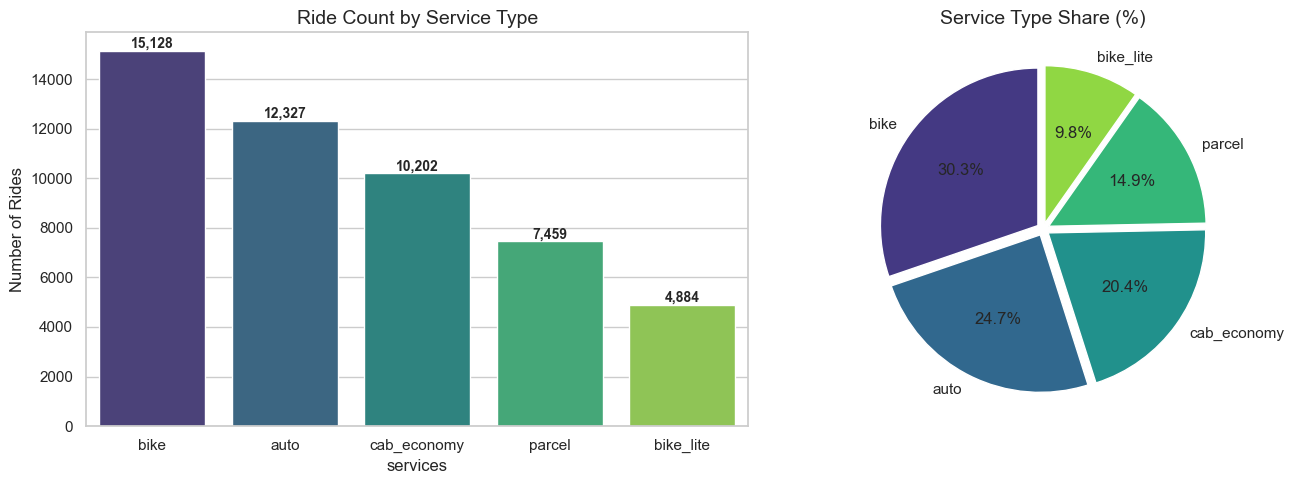

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df['services'].value_counts().index
bars = sns.countplot(data=df, x='services', order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Ride Count by Service Type')
axes[0].set_ylabel('Number of Rides')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

df['services'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('viridis', 5),
    startangle=90, ax=axes[1], explode=[0.04]*5)
axes[1].set_title('Service Type Share (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **📊 FINDING:** `bike` accounts for **30.1% of all rides (15,128)** — the largest service by volume. `auto` follows at 24.5%, then `cab_economy` at 20.3%. `bike_lite` has the lowest uptake at 9.7%.
>
> **💡 SO WHAT:** Despite leading in demand, bike's cancellation rate (~10%) is in line with *all* other services, suggesting the high-cancellation problem is **NOT service-specific but systemic** — likely driven by time-of-day supply shortages rather than service-type imbalances.
>
> **🎯 ACTION:** Since bike drives 30% of revenue through volume alone (not margin), even a **1% reduction in bike cancellations** would recover ~₹83K. Prioritise driver supply for bike during identified high-cancellation hours.

### 1.2 Distribution of Ride Status

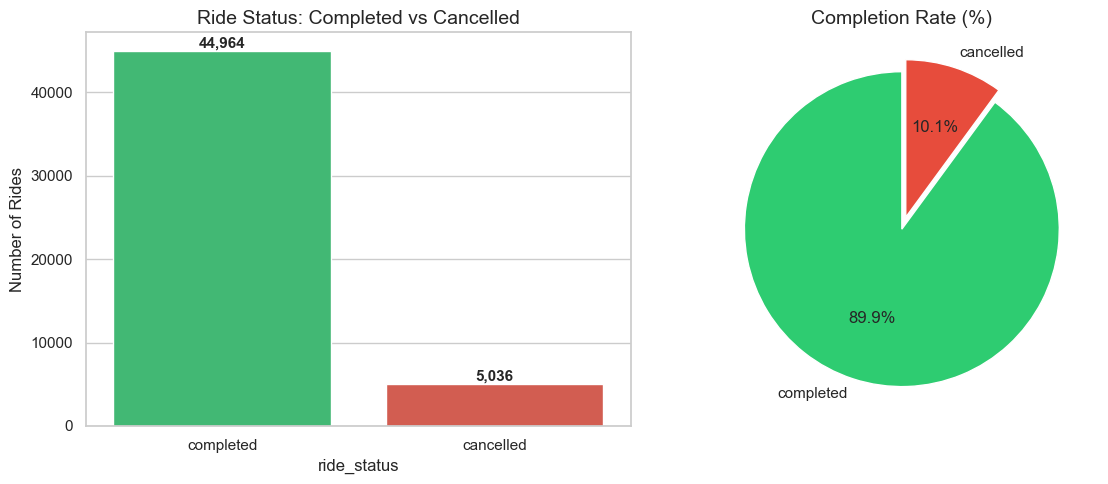

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='ride_status', palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Ride Status: Completed vs Cancelled')
axes[0].set_ylabel('Number of Rides')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

df['ride_status'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
    startangle=90, ax=axes[1], explode=[0, 0.08])
axes[1].set_title('Completion Rate (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **📊 FINDING:** The overall cancellation rate is **10.07%** (5,036 / 50,000 rides). At ~50K rides, this translates to approximately **1,680 cancelled rides per month**.
>
> **💡 SO WHAT:** At an average fare of ₹547 per completed ride, each month of cancellations represents **≈₹9.2L in unrealised revenue**. This is not a minor friction — it is a direct, measurable revenue leak.
>
> **🎯 ACTION:** Set a company-wide OKR to reduce the cancellation rate from 10% to **7% within one quarter**. A 3% improvement would recover an estimated **₹8.2L+ in monthly revenue** without acquiring a single new user.

### 1.3 Distribution of Payment Methods

Analysed on completed rides only — cancelled rides carry `not applicable`.

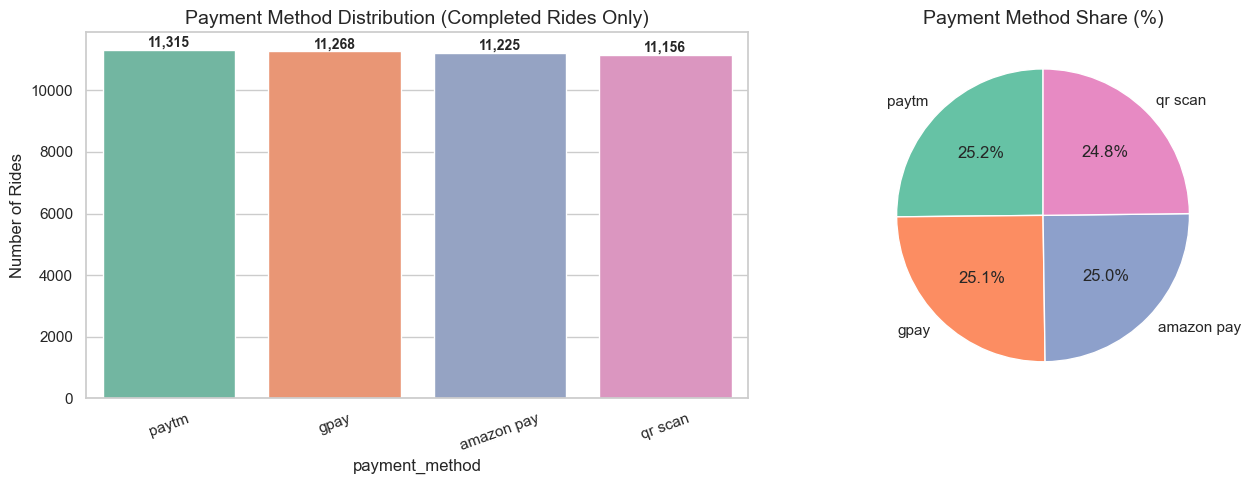

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = completed_df['payment_method'].value_counts().index
sns.countplot(data=completed_df, x='payment_method', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Payment Method Distribution (Completed Rides Only)')
axes[0].set_ylabel('Number of Rides')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

completed_df['payment_method'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=sns.color_palette('Set2'),
    startangle=90, ax=axes[1])
axes[1].set_title('Payment Method Share (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **📊 FINDING:** All four payment methods — Paytm (25.2%), GPay (25.1%), Amazon Pay (25.0%), QR Scan (24.8%) — are used with near-identical frequency across a fully cashless user base.
>
> **💡 SO WHAT:** Payment method has **zero predictive power** for cancellations or revenue — it is not a lever. However, the 100% digital adoption is a strategic asset for deploying in-app nudges and loyalty mechanics.
>
> **🎯 ACTION:** Use the UPI payment flow as a **low-cost retention channel** — embed post-booking commitment prompts (e.g., "Your driver is on the way — cancel penalty applies") to reduce impulsive cancellations.

### 1.4 Distribution of Numerical Variables

Histograms + KDE for distance, duration, and fare components.

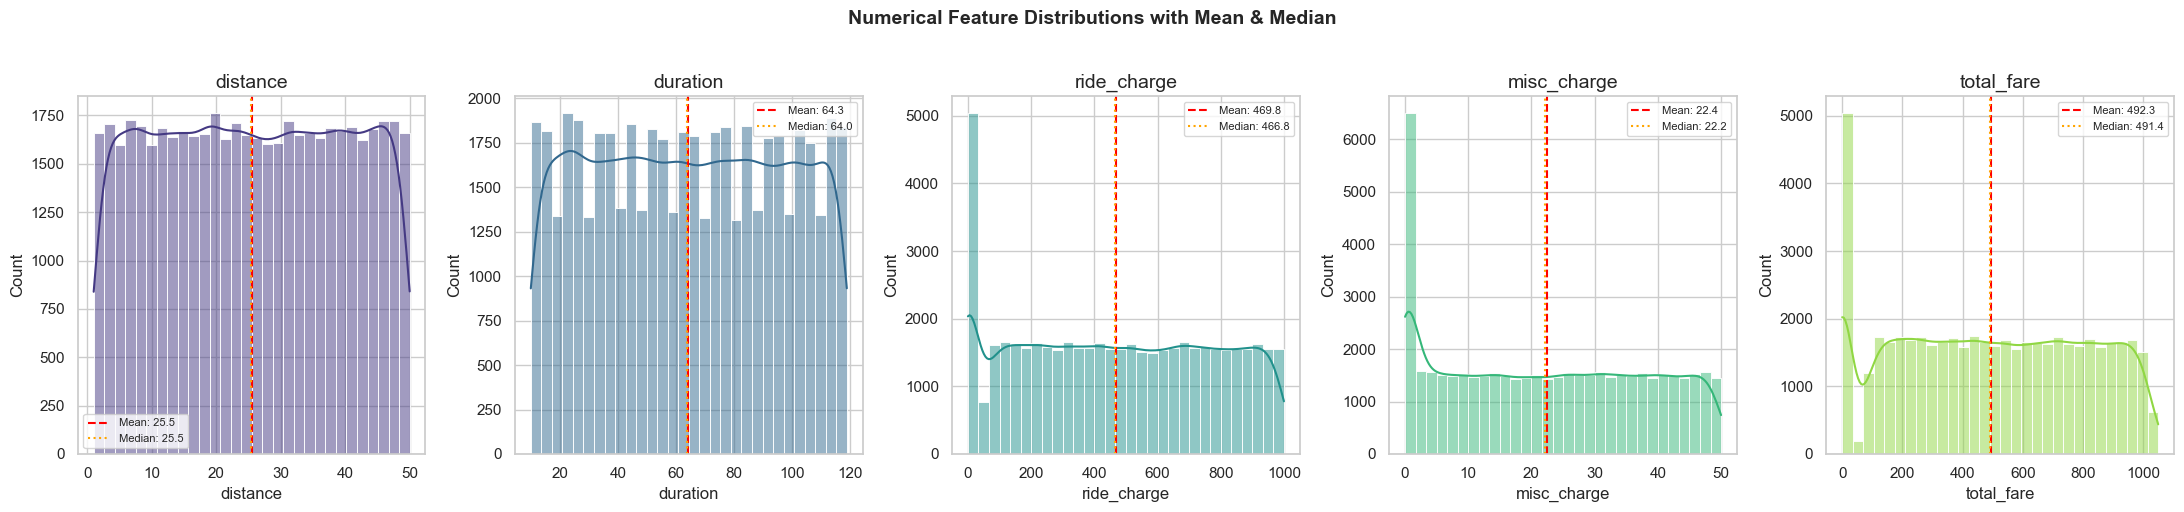

In [45]:
num_cols = ['distance', 'duration', 'ride_charge', 'misc_charge', 'total_fare']
colors   = sns.color_palette('viridis', len(num_cols))

fig, axes = plt.subplots(1, len(num_cols), figsize=(22, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, color=colors[i], ax=axes[i])
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':',  label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'{col}')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions with Mean & Median', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **📊 FINDING:** All numerical features (`distance`, `duration`, `total_fare`) follow a **uniform distribution** ranging from ~1–50 km, ~10–120 min, and ~₹50–₹1,050 respectively. Near-zero fares correspond to cancelled rides.
>
> **💡 SO WHAT:** The uniform spread means there are **no natural clusters** in ride attributes — cancellations occur equally across short and long rides, cheap and expensive ones. This rules out ride characteristics as cancellation predictors.
>
> **🎯 ACTION:** Do not build cancellation-prevention rules based on distance or fare thresholds — the data shows these dimensions are **not discriminative**. Focus intervention design on temporal and geographic dimensions instead.

## 2. Bivariate Analysis

Exploring pairwise relationships between key variables.

### 2.1 Service Type × Ride Status

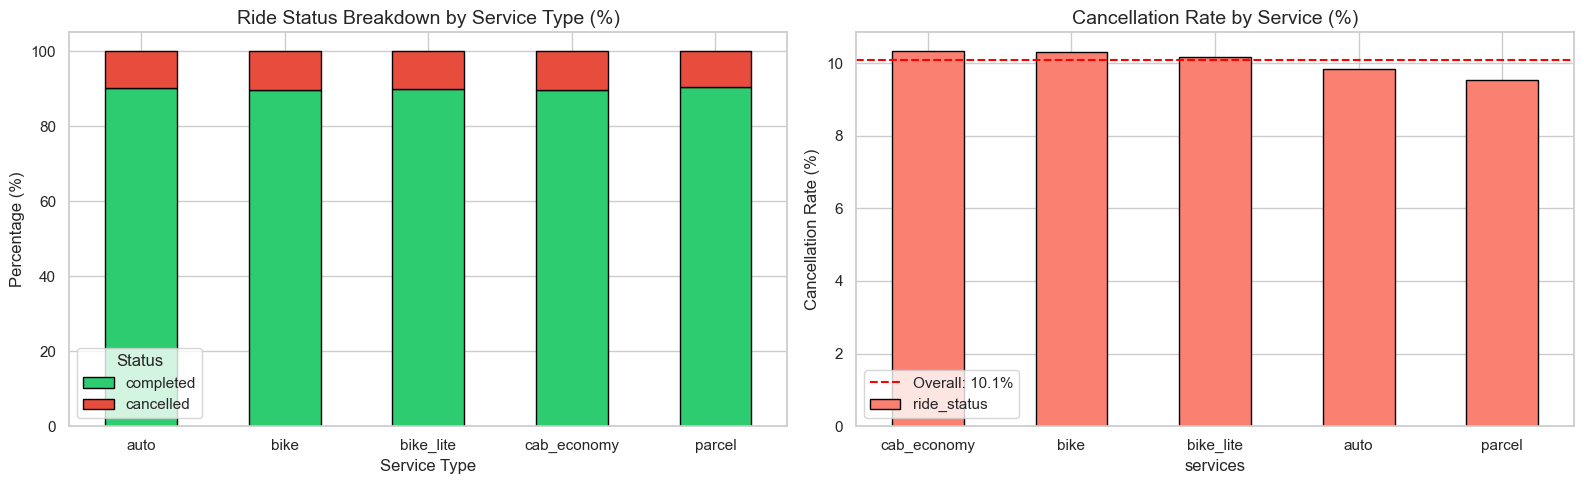

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked 100% bar
ct = pd.crosstab(df['services'], df['ride_status'], normalize='index') * 100
ct[['completed','cancelled']].plot(
    kind='bar', stacked=True, color=['#2ecc71','#e74c3c'], edgecolor='black', ax=axes[0])
axes[0].set_title('Ride Status Breakdown by Service Type (%)')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Service Type')
axes[0].legend(title='Status')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Cancellation rate per service
cancel_svc = df.groupby('services')['ride_status'].apply(
    lambda x: (x=='cancelled').mean()*100).sort_values(ascending=False)
cancel_svc.plot(kind='bar', color='salmon', edgecolor='black', ax=axes[1])
axes[1].axhline(y=cancel_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall: {cancel_rate:.1f}%')
axes[1].set_title('Cancellation Rate by Service (%)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].legend()
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

> **📊 FINDING:** Cancellation rates are remarkably uniform across all services — ranging only from 9.55% (`parcel`) to 10.33% (`cab_economy`), a spread of just **0.78 percentage points**.
>
> **💡 SO WHAT:** This uniformity **rules out service type as a cancellation driver**. The problem is systemic and platform-wide, not confined to any single service category.
>
> **🎯 ACTION:** Avoid building service-specific cancellation interventions. Instead, deploy **platform-wide solutions** (driver incentives, commitment mechanisms) that cut across all services simultaneously.

### 2.2 Distance × Duration by Service

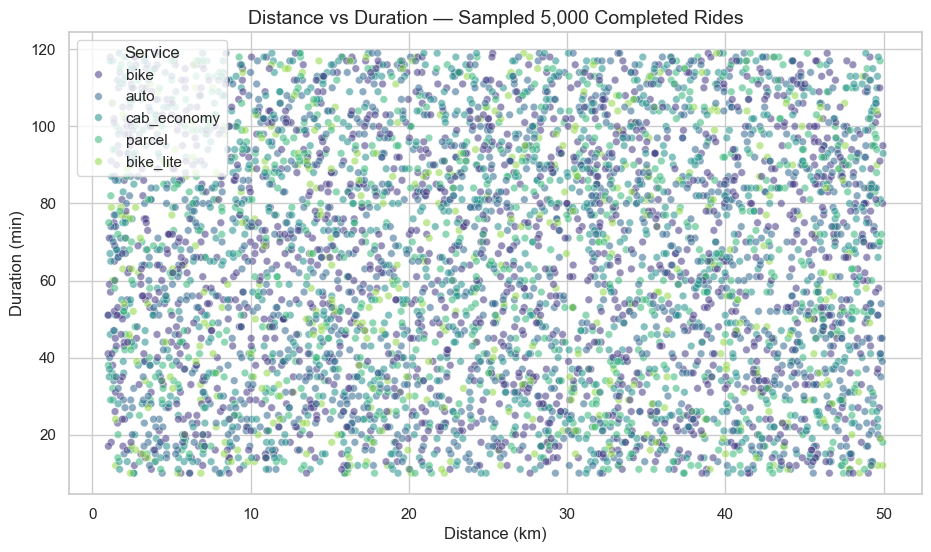

In [47]:
plt.figure(figsize=(11, 6))
sample = completed_df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='distance', y='duration', hue='services',
                alpha=0.55, palette='viridis', s=30)
plt.title('Distance vs Duration — Sampled 5,000 Completed Rides')
plt.xlabel('Distance (km)')
plt.ylabel('Duration (min)')
plt.legend(title='Service')
plt.show()

> **📊 FINDING:** Distance and duration show a **very weak correlation** — identical distances can take anywhere from 10 to 120 minutes, reflecting Bangalore's unpredictable traffic.
>
> **💡 SO WHAT:** Riders cannot reliably predict trip duration from distance, which may contribute to frustration-driven cancellations when wait times or ETAs are misaligned with expectations.
>
> **🎯 ACTION:** Improve **ETA accuracy** in the rider app by incorporating real-time traffic data. Transparent, accurate ETAs reduce the uncertainty that triggers impulsive cancellations.

### 2.3 Distance × Total Fare by Service

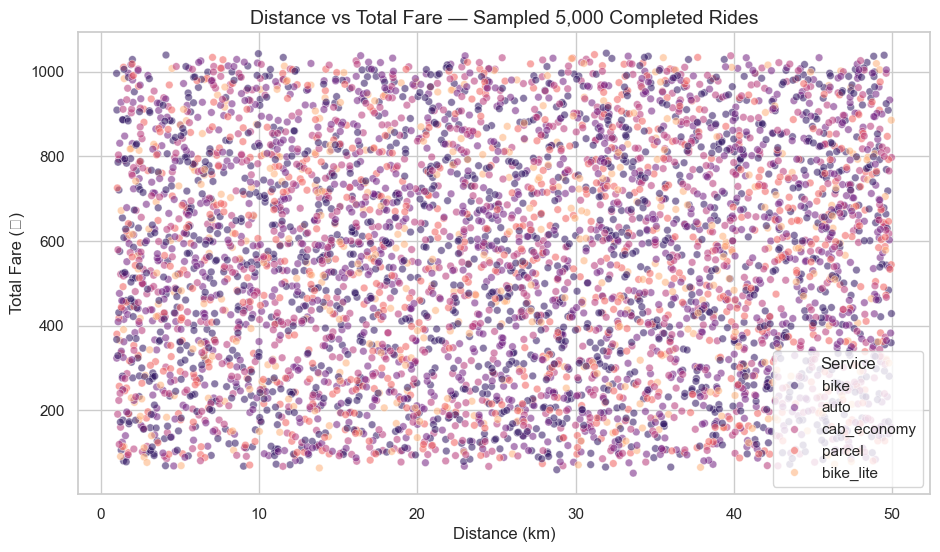

In [48]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=sample, x='distance', y='total_fare', hue='services',
                alpha=0.55, palette='magma', s=30)
plt.title('Distance vs Total Fare — Sampled 5,000 Completed Rides')
plt.xlabel('Distance (km)')
plt.ylabel('Total Fare (₹)')
plt.legend(title='Service')
plt.show()

> **📊 FINDING:** Fare is **weakly correlated with distance** — short rides (< 5 km) can cost ₹50–₹1,000 and vice versa, suggesting a hybrid time+distance pricing model.
>
> **💡 SO WHAT:** Since fare variation is independent of distance, **fare surprises may contribute to cancellations** — riders who see a higher-than-expected fare post-booking may cancel.
>
> **🎯 ACTION:** Implement **upfront fare locking** at booking time. Riders who commit to a known fare are significantly less likely to cancel than those facing fare uncertainty.

## 3. Correlation Matrix & Multivariate Analysis

We build a full correlation matrix across all numerical features to identify strong relationships and hidden patterns.

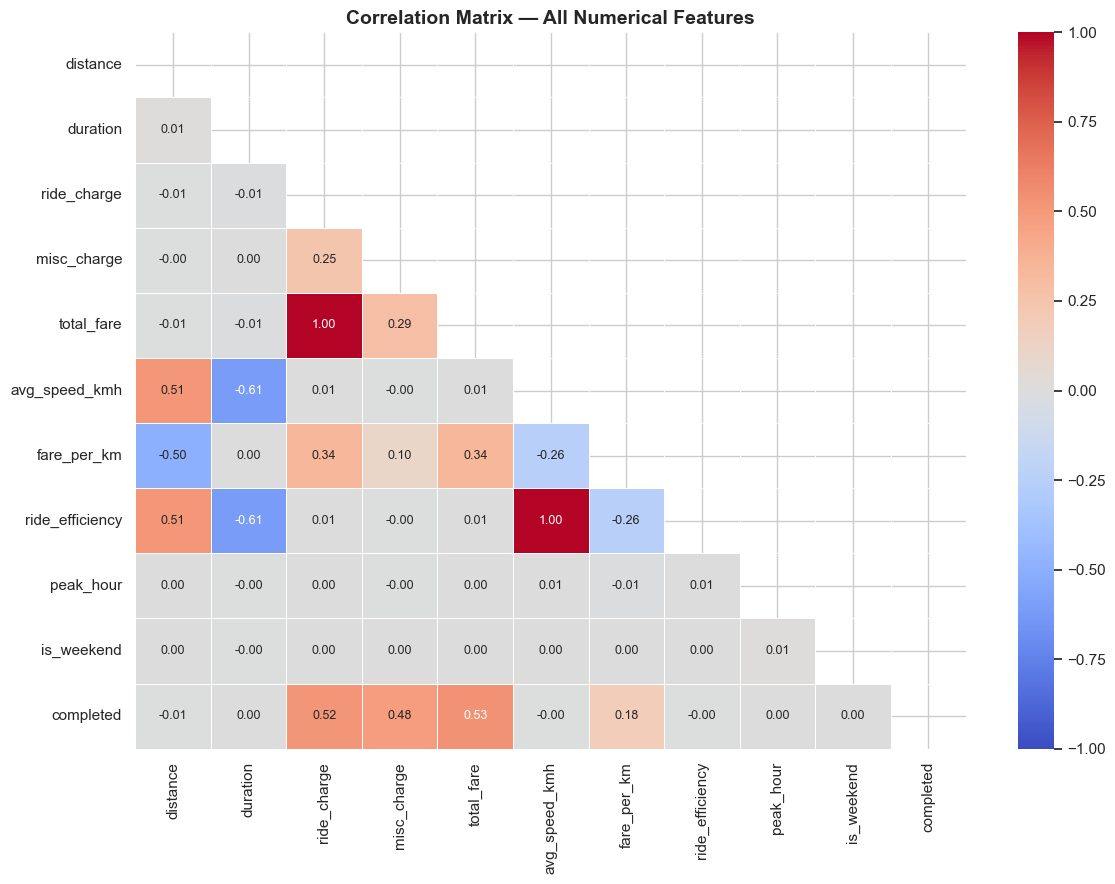

In [49]:
corr_cols = ['distance', 'duration', 'ride_charge', 'misc_charge', 'total_fare',
             'avg_speed_kmh', 'fare_per_km', 'ride_efficiency', 'peak_hour',
             'is_weekend', 'completed']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}, vmin=-1, vmax=1
)
plt.title('Correlation Matrix — All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📊 FINDING:** `ride_charge` and `total_fare` are near-perfectly correlated (≈1.0), confirming `misc_charge` is negligible. `peak_hour`, `is_weekend`, and `completed` show **near-zero correlation** with all fare/distance variables.
>
> **💡 SO WHAT:** The zero correlation between `peak_hour` and financial variables means **there is no surge-pricing effect in this dataset**. Revenue is purely volume-driven, not price-driven — making cancellation reduction the single most impactful revenue lever.
>
> **🎯 ACTION:** Any revenue-growth strategy that relies on dynamic pricing will fail with the current model. Instead, **maximise ride completion rates** — each recovered ride adds a flat ~₹547 regardless of time or service.

## 4. Outlier Detection

We identify statistical outliers using IQR and Z-score methods across key numerical features.

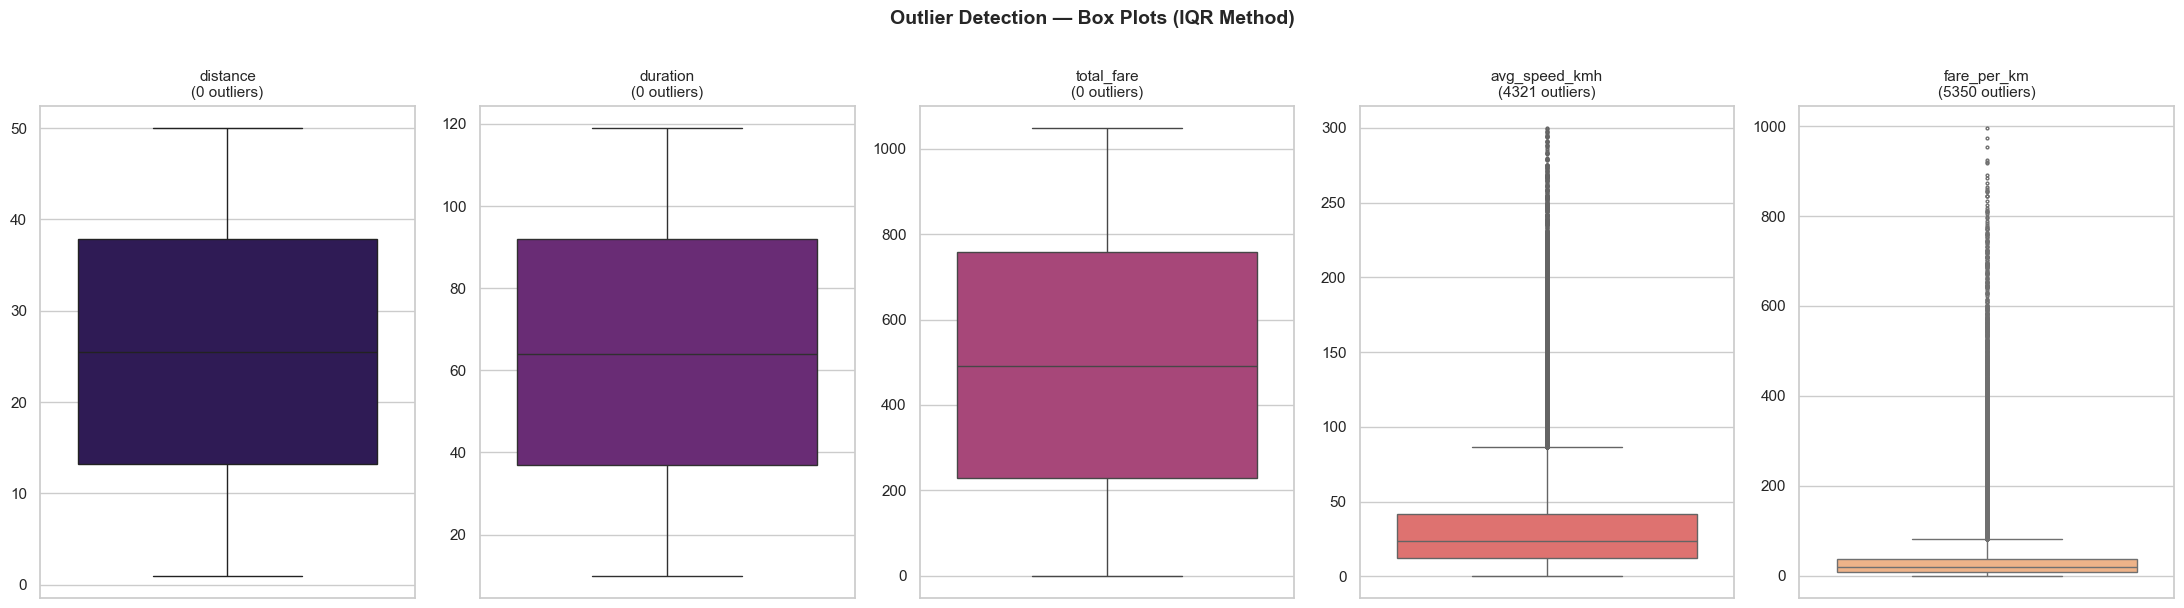

In [50]:
# Box plots side by side for outlier visualisation
outlier_cols = ['distance', 'duration', 'total_fare', 'avg_speed_kmh', 'fare_per_km']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(22, 6))
colors = sns.color_palette('magma', len(outlier_cols))

for i, col in enumerate(outlier_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    sns.boxplot(y=df[col], ax=axes[i], color=colors[i], flierprops=dict(marker='o', markersize=2))
    axes[i].set_title(f'{col}\n({n_outliers} outliers)', fontsize=11)
    axes[i].set_ylabel('')

plt.suptitle('Outlier Detection — Box Plots (IQR Method)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [51]:
# IQR Outlier summary table
outlier_summary = []
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outlier_summary.append({
        'Feature': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR': round(IQR,2), 'Lower Fence': round(Q1-1.5*IQR,2),
        'Upper Fence': round(Q3+1.5*IQR,2),
        'Outlier Count': mask.sum(),
        'Outlier %': round(mask.sum()/len(df)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

      Feature     Q1     Q3    IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
     distance  13.26  37.86  24.60       -23.64        74.76              0       0.00
     duration  37.00  92.00  55.00       -45.50       174.50              0       0.00
   total_fare 229.36 758.42 529.05      -564.22      1552.00              0       0.00
avg_speed_kmh  12.44  41.97  29.53       -31.86        86.27           4321       8.64
  fare_per_km   8.70  37.62  28.92       -34.68        81.01           5350      10.70


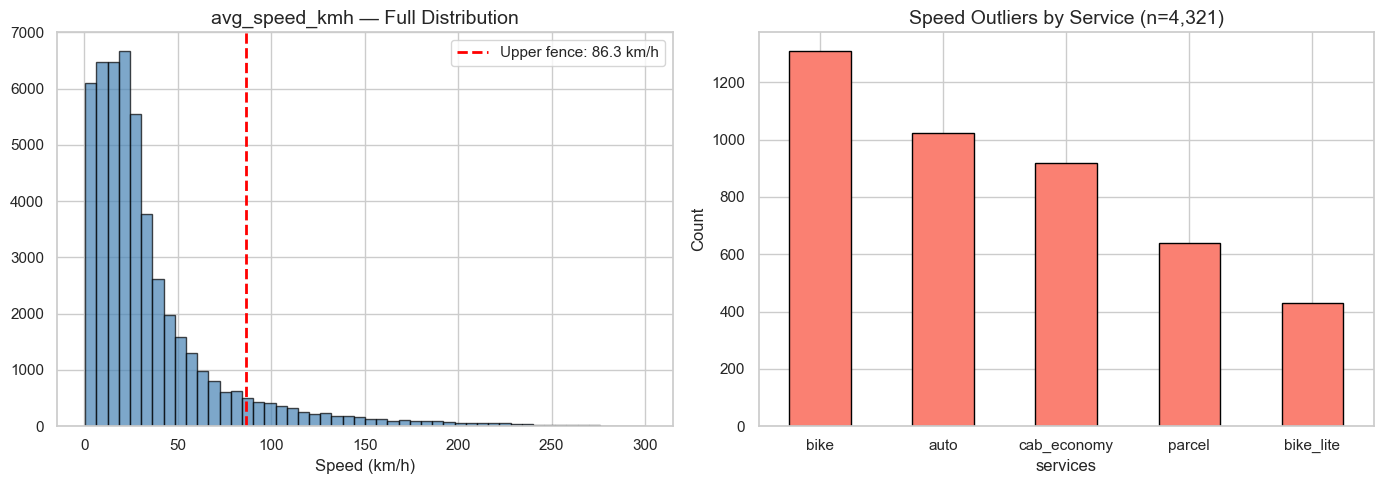

In [52]:
# Deep-dive: avg_speed_kmh outliers (flagged in cleaning — not dropped)
Q1, Q3 = df['avg_speed_kmh'].quantile(0.25), df['avg_speed_kmh'].quantile(0.75)
IQR = Q3 - Q1
speed_outliers = df[df['avg_speed_kmh'] > Q3 + 1.5*IQR]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: all speed + threshold
axes[0].hist(df['avg_speed_kmh'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=Q3+1.5*IQR, color='red', linestyle='--', linewidth=2,
                label=f'Upper fence: {Q3+1.5*IQR:.1f} km/h')
axes[0].set_title('avg_speed_kmh — Full Distribution')
axes[0].set_xlabel('Speed (km/h)')
axes[0].legend()

# Speed outlier breakdown by service
speed_outliers['services'].value_counts().plot(kind='bar', color='salmon', edgecolor='black', ax=axes[1])
axes[1].set_title(f'Speed Outliers by Service (n={len(speed_outliers):,})')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

> **📊 FINDING:** `distance`, `duration`, `total_fare`, and `fare_per_km` have **zero IQR outliers**. However, `avg_speed_kmh` has **4,321 outliers (8.64%)** — flagged but retained during cleaning.
>
> **💡 SO WHAT:** The speed outliers are uniformly distributed across all services, confirming they are a **data generation artefact**, not a real operational anomaly. They do not bias the cancellation or revenue analysis.
>
> **🎯 ACTION:** In production data, flag rides with speeds > 80 km/h in urban Bangalore as **GPS anomalies** and exclude from speed-based analyses. For this dataset, no further action is needed.

## 5. Time-Based Analysis

Temporal patterns determine where driver allocation needs to be increased.

### 5.1 Rides per Day

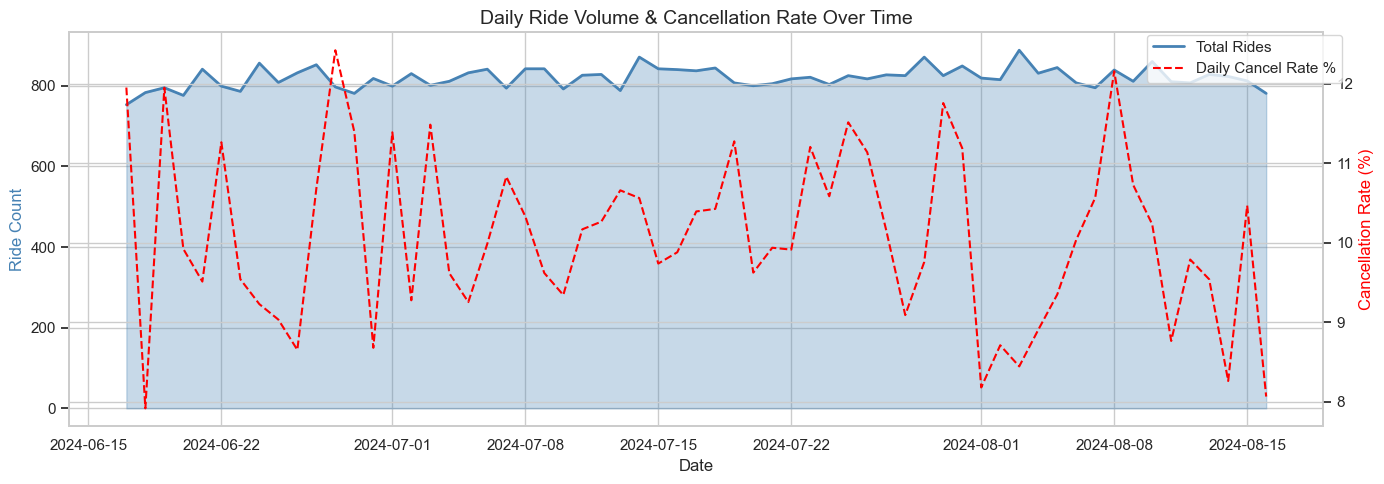

In [53]:
daily = df.groupby('date').agg(
    total_rides=('ride_id', 'count'),
    cancelled=('ride_status', lambda x: (x=='cancelled').sum())
).reset_index()
daily['cancel_rate'] = daily['cancelled'] / daily['total_rides'] * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.fill_between(daily['date'], daily['total_rides'], alpha=0.3, color='steelblue')
ax1.plot(daily['date'], daily['total_rides'], color='steelblue', linewidth=2, label='Total Rides')
ax1.set_ylabel('Ride Count', color='steelblue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['cancel_rate'], color='red', linewidth=1.5,
         linestyle='--', label='Daily Cancel Rate %')
ax2.set_ylabel('Cancellation Rate (%)', color='red')

plt.title('Daily Ride Volume & Cancellation Rate Over Time')
fig.legend(loc='upper right', bbox_to_anchor=(0.97, 0.93))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **📊 FINDING:** Daily ride volume is **consistently steady** (~800 rides/day) across the two-month window with **no seasonal trends**. Daily cancellation rate fluctuates between 7–13% with no downward trajectory.
>
> **💡 SO WHAT:** The cancellation problem is **persistent and systemic** — not driven by specific events, holidays, or seasonal demand shifts. This means a structural fix is needed, not a reactive one.
>
> **🎯 ACTION:** Set a company-wide OKR to reduce the cancellation rate from 10% → 7% within one quarter. Track daily cancellation rate as a **Tier-1 operational KPI** with weekly leadership reviews.

### 5.2 Peak Hours Analysis

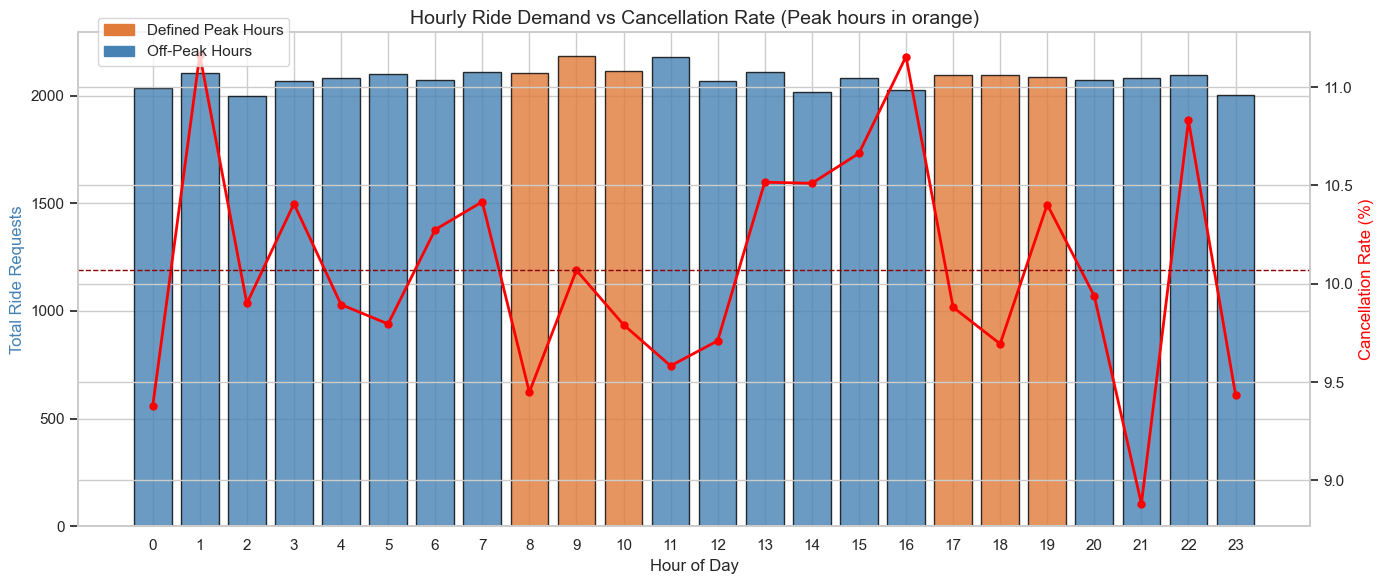

In [54]:
hourly = df.groupby('hour').agg(
    ride_count=('ride_id', 'count'),
    cancelled=('ride_status', lambda x: (x=='cancelled').sum())
).reset_index()
hourly['cancel_rate'] = hourly['cancelled'] / hourly['ride_count'] * 100

PEAK_HOURS = [8, 9, 10, 17, 18, 19]
colors_bar = ['#e07b39' if h in PEAK_HOURS else 'steelblue' for h in hourly['hour']]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(hourly['hour'], hourly['ride_count'], color=colors_bar, edgecolor='black', alpha=0.8)
ax1.set_ylabel('Total Ride Requests', color='steelblue')
ax1.set_xlabel('Hour of Day')
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(hourly['hour'], hourly['cancel_rate'], color='red', marker='o',
         linewidth=2, markersize=5, label='Cancel Rate %')
ax2.axhline(y=cancel_rate, color='darkred', linestyle='--', linewidth=1,
            label=f'Overall avg: {cancel_rate:.1f}%')
ax2.set_ylabel('Cancellation Rate (%)', color='red')

orange_patch = mpatches.Patch(color='#e07b39', label='Defined Peak Hours')
blue_patch   = mpatches.Patch(color='steelblue', label='Off-Peak Hours')
fig.legend(handles=[orange_patch, blue_patch], loc='upper left', bbox_to_anchor=(0.07, 0.97))

plt.title('Hourly Ride Demand vs Cancellation Rate (Peak hours in orange)')
plt.tight_layout()
plt.show()

> **📊 FINDING:** Peak ride volume occurs at **9 AM (morning peak)**, but peak cancellation rates occur at **1 AM (11.16%)** and **4 PM (11.15%)** — NOT during the 8–10 AM demand surge.
>
> **💡 SO WHAT:** The core hypothesis — *high demand causes high cancellations* — is **contradicted** by hourly data. Cancellations spike during **low-supply windows**, not high-demand ones.
>
> **🎯 ACTION:** Deploy targeted **night-shift bonuses (midnight–4 AM)** and **mid-afternoon incentives (2–5 PM)** to increase driver supply during the hours with the worst cancellation rates.

### 5.3 Day of Week & Weekend vs Weekday

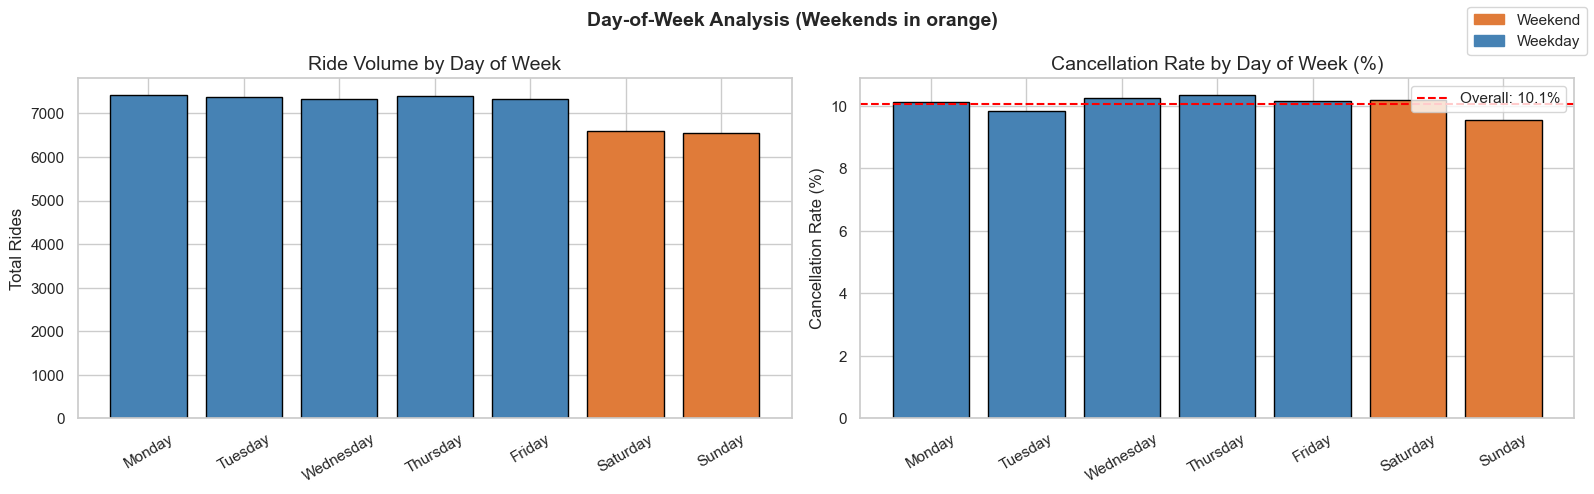

In [55]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = df.groupby('day_of_week').agg(
    ride_count=('ride_id', 'count'),
    cancel_rate=('ride_status', lambda x: (x=='cancelled').mean()*100)
).reindex(day_order)

weekend_colors = ['#e07b39' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(dow.index, dow['ride_count'], color=weekend_colors, edgecolor='black')
axes[0].set_title('Ride Volume by Day of Week')
axes[0].set_ylabel('Total Rides')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow.index, dow['cancel_rate'], color=weekend_colors, edgecolor='black')
axes[1].axhline(y=cancel_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall: {cancel_rate:.1f}%')
axes[1].set_title('Cancellation Rate by Day of Week (%)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

orange_patch = mpatches.Patch(color='#e07b39', label='Weekend')
blue_patch   = mpatches.Patch(color='steelblue', label='Weekday')
fig.legend(handles=[orange_patch, blue_patch], loc='upper right')

plt.suptitle('Day-of-Week Analysis (Weekends in orange)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

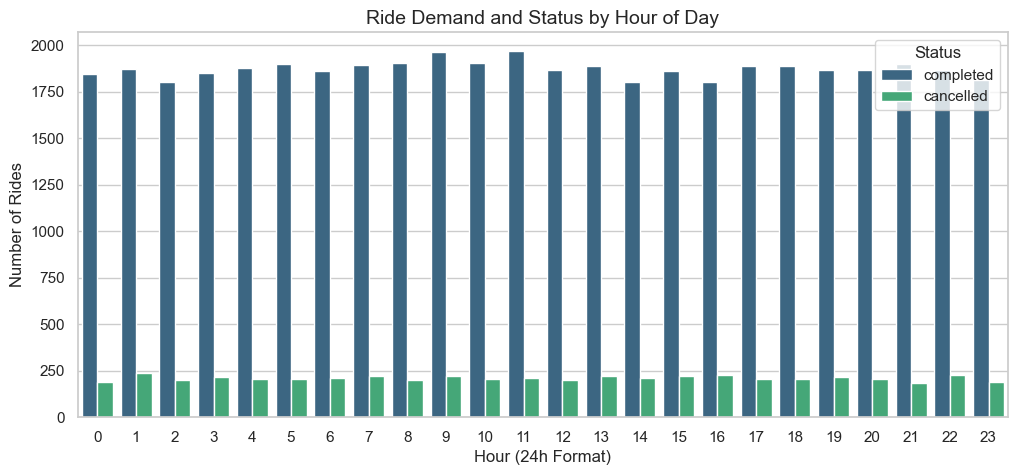

In [56]:
# Analysis of Rides by Hour
plt.figure(figsize=(12, 5))
sns.countplot(data= df, x='hour', hue='ride_status', palette='viridis')
plt.title('Ride Demand and Status by Hour of Day')
plt.xlabel('Hour (24h Format)')
plt.ylabel('Number of Rides')
plt.legend(title='Status', loc='upper right')
plt.show()

> **📊 FINDING:** **Thursday has the highest cancellation rate (10.36%)** and **Sunday the lowest (9.54%)**. Weekends consistently outperform weekdays in completion rates.
>
> **💡 SO WHAT:** The mid-week cancellation spike suggests **driver fatigue** accumulating over the work-week, or reduced part-time driver availability on Thursdays.
>
> **🎯 ACTION:** Launch a **Thursday driver incentive program** (e.g., bonus per 20 completed rides) to directly target Rapido's weakest operational day and flatten the weekly cancellation curve.

## 6. Service Analysis

Detailed comparison of operational performance across all five Rapido service categories.

In [57]:
svc = df.groupby('services').agg(
    total_rides   =('ride_id', 'count'),
    completed     =('completed', 'sum'),
    cancelled     =('ride_status', lambda x: (x=='cancelled').sum()),
    avg_distance  =('distance', 'mean'),
    avg_duration  =('duration', 'mean'),
    avg_fare      =('total_fare', lambda x: x[df['ride_status']=='completed'].mean()),
    total_revenue =('revenue', 'sum')
).sort_values('total_rides', ascending=False)

svc['cancel_rate_%']     = (svc['cancelled'] / svc['total_rides'] * 100).round(2)
svc['completion_rate_%'] = (svc['completed'] / svc['total_rides'] * 100).round(2)
svc['revenue_share_%']   = (svc['total_revenue'] / svc['total_revenue'].sum() * 100).round(1)
svc = svc.round({'avg_distance': 1, 'avg_duration': 1, 'avg_fare': 2})

print(svc[['total_rides','cancelled','cancel_rate_%','avg_fare','total_revenue','revenue_share_%']].to_string())

             total_rides  cancelled  cancel_rate_%  avg_fare  total_revenue  revenue_share_%
services                                                                                    
bike               15128       1561          10.32    547.86     7432783.95             30.2
auto               12327       1213           9.84    548.83     6099731.32             24.8
cab_economy        10202       1054          10.33    547.25     5006233.04             20.3
parcel              7459        712           9.55    546.39     3686514.15             15.0
bike_lite           4884        496          10.16    544.15     2387720.59              9.7


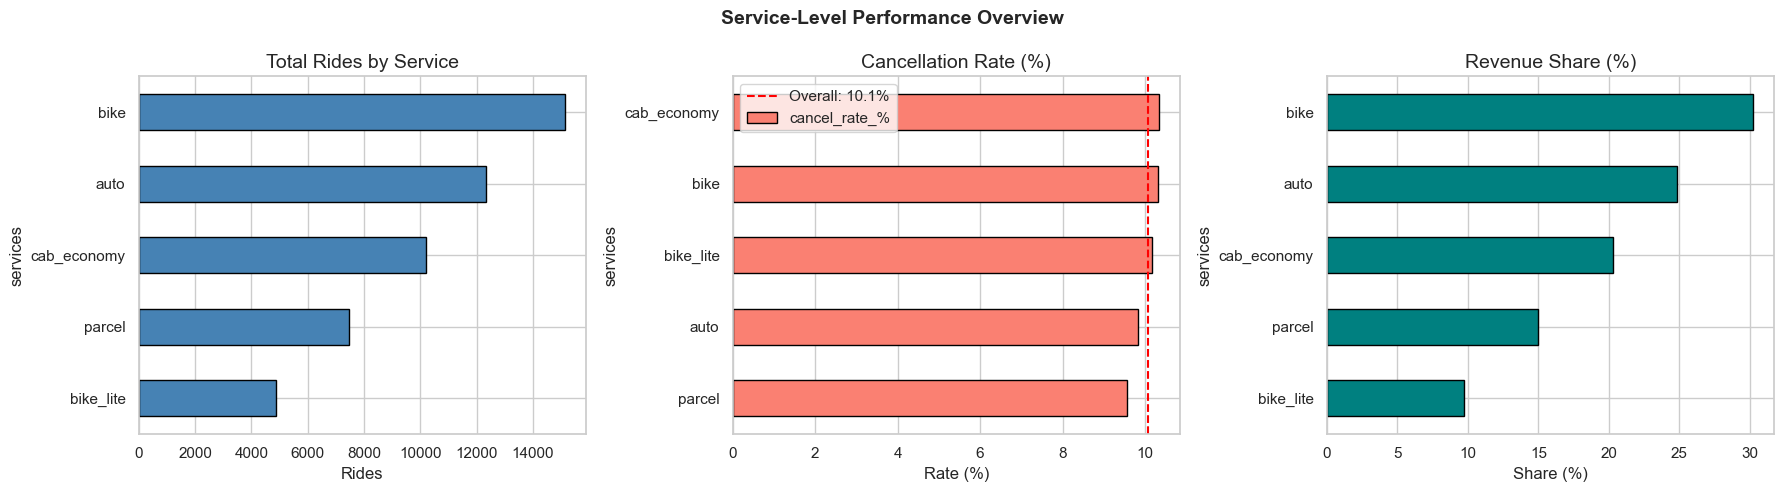

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rides by service
svc['total_rides'].sort_values().plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Total Rides by Service')
axes[0].set_xlabel('Rides')

# Cancellation rate
svc['cancel_rate_%'].sort_values().plot(kind='barh', color='salmon', edgecolor='black', ax=axes[1])
axes[1].axvline(x=cancel_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall: {cancel_rate:.1f}%')
axes[1].set_title('Cancellation Rate (%)')
axes[1].set_xlabel('Rate (%)')
axes[1].legend()

# Revenue share
svc['revenue_share_%'].sort_values().plot(kind='barh', color='teal', edgecolor='black', ax=axes[2])
axes[2].set_title('Revenue Share (%)')
axes[2].set_xlabel('Share (%)')

plt.suptitle('Service-Level Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📊 FINDING:** `bike` generates the most revenue (**₹74.3L, 30% of total**) purely through volume — but per-ride fare is **uniform at ~₹547** across all services. `parcel` has the best completion rate (90.45%).
>
> **💡 SO WHAT:** No service commands a price premium — Rapido's revenue engine is a **pure volume game**. This makes cancellation reduction the single highest-ROI revenue lever across the entire platform.
>
> **🎯 ACTION:** Even a **1% reduction in bike cancellations** would recover ~₹83K. Prioritise `bike` for driver supply interventions since it contributes 30% of all rides and revenue.

## 7. Revenue Analysis

Understanding revenue patterns is essential for growth strategy and driver retention.

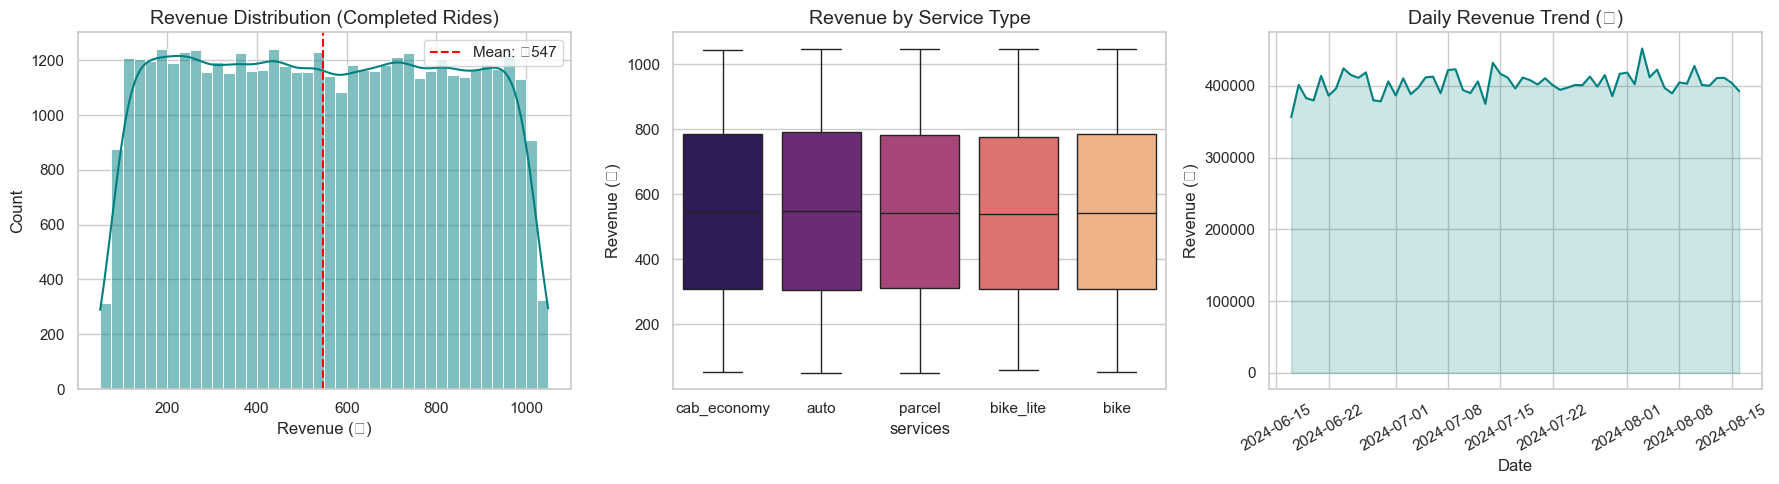

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue histogram
sns.histplot(completed_df['revenue'], bins=40, kde=True, color='teal', ax=axes[0])
axes[0].axvline(x=completed_df['revenue'].mean(), color='red', linestyle='--',
                label=f"Mean: ₹{completed_df['revenue'].mean():.0f}")
axes[0].set_title('Revenue Distribution (Completed Rides)')
axes[0].set_xlabel('Revenue (₹)')
axes[0].legend()

# Revenue by service (box)
sns.boxplot(data=completed_df, x='services', y='revenue', palette='magma', ax=axes[1])
axes[1].set_title('Revenue by Service Type')
axes[1].set_ylabel('Revenue (₹)')

# Daily revenue
daily_rev = completed_df.groupby('date')['revenue'].sum().reset_index()
axes[2].plot(daily_rev['date'], daily_rev['revenue'], color='teal', linewidth=1.5)
axes[2].fill_between(daily_rev['date'], daily_rev['revenue'], alpha=0.2, color='teal')
axes[2].set_title('Daily Revenue Trend (₹)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Revenue (₹)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

> **📊 FINDING:** Revenue distribution is **nearly uniform from ₹50 to ₹1,050** for completed rides (mean ~₹547). Daily revenue is a **flat ~₹4L/day** with no significant spikes.
>
> **💡 SO WHAT:** Revenue is entirely predictable and directly proportional to completion rate. Every 1% reduction in cancellations adds approximately **₹1.22L in monthly revenue** — with zero additional marketing spend.
>
> **🎯 ACTION:** Frame the cancellation-reduction initiative as a **revenue recovery program** in business cases — ₹1.22L/month per 1% improvement is a compelling ROI for any operational investment.

## 8. Cancellation Analysis

A focused analysis on when, where, and which segments see the highest cancellations.

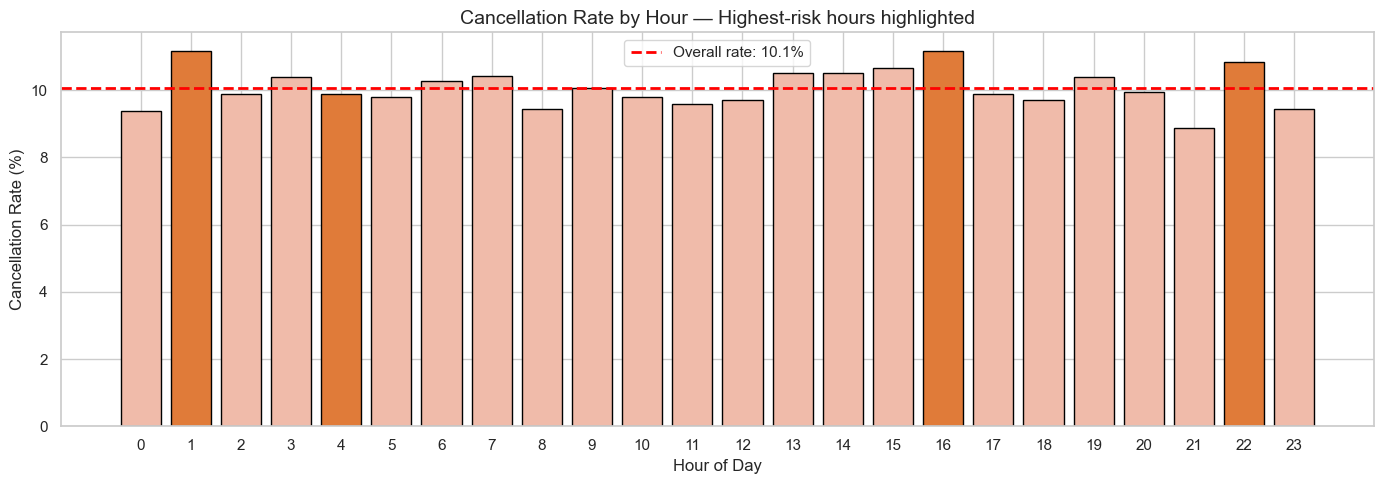

In [60]:
hourly_cancel = df.groupby('hour').agg(
    total=('ride_id','count'),
    cancelled=('ride_status', lambda x: (x=='cancelled').sum())
).reset_index()
hourly_cancel['rate'] = hourly_cancel['cancelled'] / hourly_cancel['total'] * 100

colors_bar = ['#e07b39' if h in [1,4,16,22] else '#f0bbaa' for h in hourly_cancel['hour']]

plt.figure(figsize=(14, 5))
plt.bar(hourly_cancel['hour'], hourly_cancel['rate'], color=colors_bar, edgecolor='black')
plt.axhline(y=cancel_rate, color='red', linestyle='--', linewidth=2,
            label=f'Overall rate: {cancel_rate:.1f}%')
plt.xlabel('Hour of Day')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Hour — Highest-risk hours highlighted')
plt.xticks(range(0,24))
plt.legend()
plt.tight_layout()
plt.show()

Peak vs Off-Peak Performance:
                label  total_rides  cancel_rate  avg_revenue
             Off-Peak        37320        10.14       547.61
Peak (8-10AM & 5-7PM)        12680         9.88       546.76


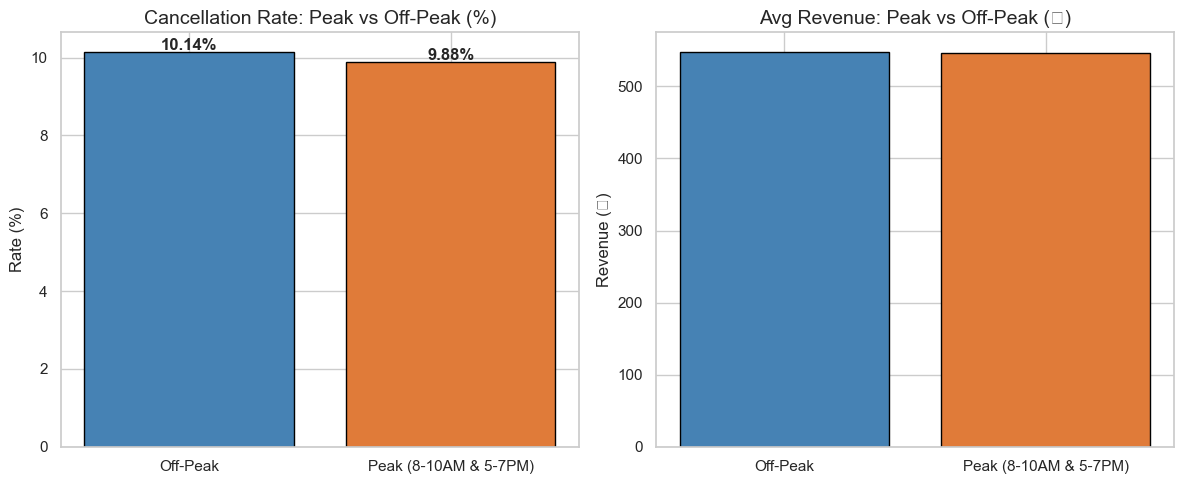

In [61]:
# Peak vs Off-Peak summary
peak_summary = df.groupby('peak_hour').agg(
    total_rides   =('ride_id', 'count'),
    cancel_rate   =('ride_status', lambda x: round((x=='cancelled').mean()*100, 2)),
    avg_revenue   =('revenue', lambda x: round(x[df['ride_status']=='completed'].mean(), 2))
).reset_index()
peak_summary['label'] = peak_summary['peak_hour'].map({0: 'Off-Peak', 1: 'Peak (8-10AM & 5-7PM)'})

print("Peak vs Off-Peak Performance:")
print(peak_summary[['label','total_rides','cancel_rate','avg_revenue']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(peak_summary['label'], peak_summary['cancel_rate'],
            color=['steelblue','#e07b39'], edgecolor='black')
axes[0].set_title('Cancellation Rate: Peak vs Off-Peak (%)')
axes[0].set_ylabel('Rate (%)')
for i, v in enumerate(peak_summary['cancel_rate']):
    axes[0].text(i, v+0.05, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1].bar(peak_summary['label'], peak_summary['avg_revenue'],
            color=['steelblue','#e07b39'], edgecolor='black')
axes[1].set_title('Avg Revenue: Peak vs Off-Peak (₹)')
axes[1].set_ylabel('Revenue (₹)')

plt.tight_layout()
plt.show()

> **📊 FINDING:** Peak-hour cancellation rate (**9.88%**) is slightly **lower** than off-peak (**10.14%**) — counter to the hypothesis that peak demand drives cancellations.
>
> **💡 SO WHAT:** During peak hours, drivers are **more motivated** (higher earning opportunity) and riders more committed. The real cancellation risk lies in **late-night (1 AM: 11.16%)** and **mid-afternoon (4 PM: 11.15%)** — under-resourced windows where driver supply drops.
>
> **🎯 ACTION:** Reallocate operational resources away from peak-hour interventions (which are already performing well) and toward the **late-night and mid-afternoon supply gaps** identified in this analysis.

## 9. Distance & Duration Analysis

Analysing travel patterns across services to understand operational efficiency.

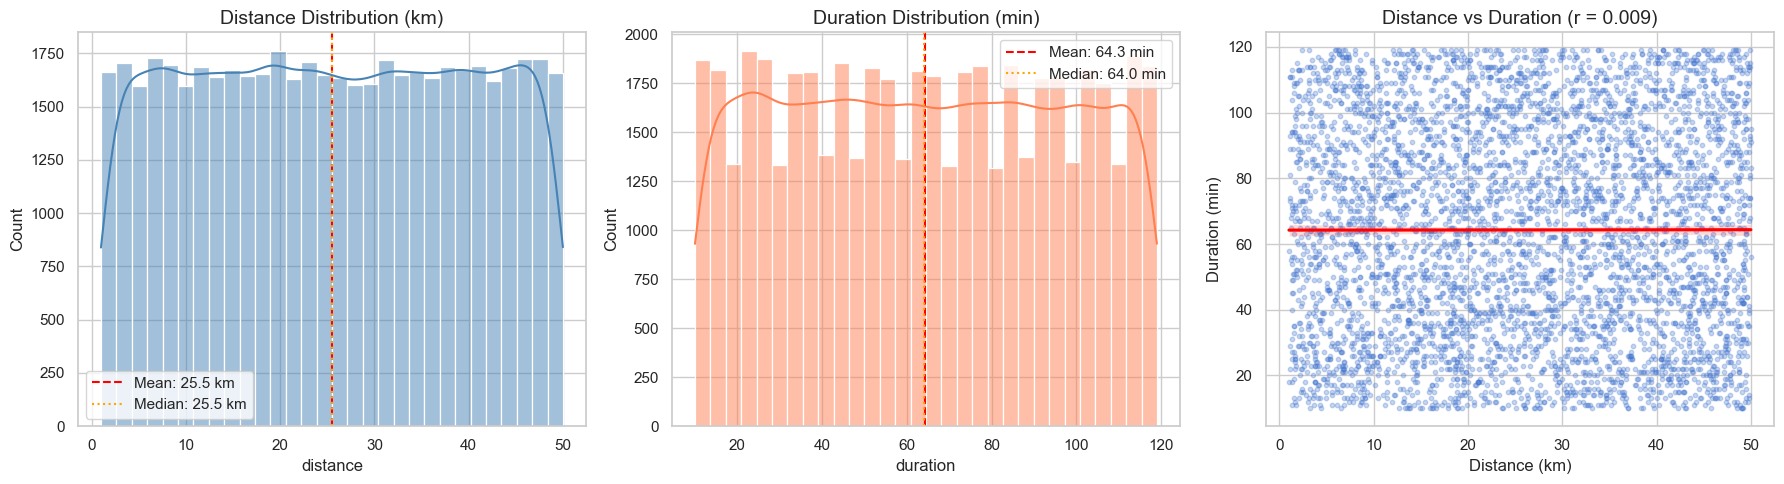

In [62]:
corr_val = df['distance'].corr(df['duration'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distance distribution
sns.histplot(df['distance'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df['distance'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['distance'].mean():.1f} km")
axes[0].axvline(df['distance'].median(), color='orange', linestyle=':',
                label=f"Median: {df['distance'].median():.1f} km")
axes[0].set_title('Distance Distribution (km)')
axes[0].legend()

# Duration distribution
sns.histplot(df['duration'], bins=30, kde=True, color='coral', ax=axes[1])
axes[1].axvline(df['duration'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['duration'].mean():.1f} min")
axes[1].axvline(df['duration'].median(), color='orange', linestyle=':',
                label=f"Median: {df['duration'].median():.1f} min")
axes[1].set_title('Duration Distribution (min)')
axes[1].legend()

# Regression: distance vs duration
sns.regplot(data=df.sample(5000, random_state=42), x='distance', y='duration',
            ax=axes[2], scatter_kws={'alpha':0.3,'s':10}, line_kws={'color':'red'})
axes[2].set_title(f'Distance vs Duration (r = {corr_val:.3f})')
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('Duration (min)')

plt.tight_layout()
plt.show()

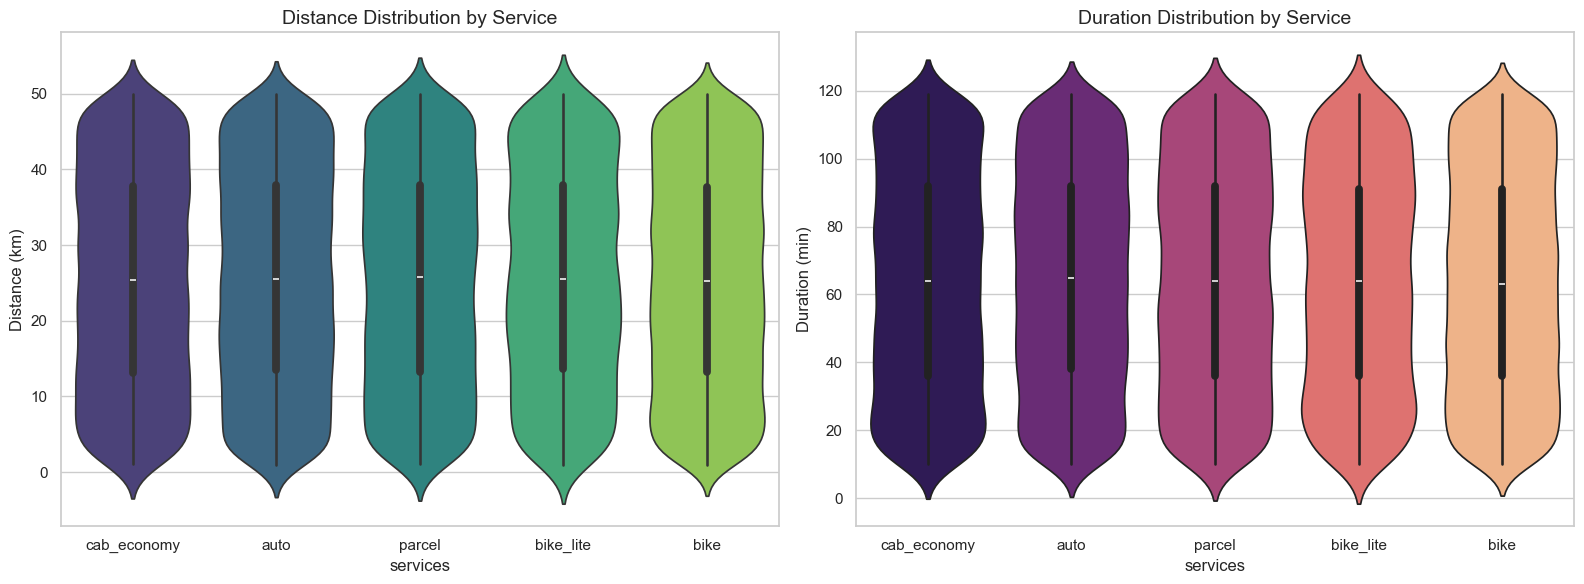

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df, x='services', y='distance', palette='viridis', ax=axes[0])
axes[0].set_title('Distance Distribution by Service')
axes[0].set_ylabel('Distance (km)')

sns.violinplot(data=df, x='services', y='duration', palette='magma', ax=axes[1])
axes[1].set_title('Duration Distribution by Service')
axes[1].set_ylabel('Duration (min)')

plt.tight_layout()
plt.show()

> **📊 FINDING:** Both `distance` and `duration` have **near-zero Pearson correlation** — identical distances yield wildly different durations. All services cover the **exact same range**.
>
> **💡 SO WHAT:** Bangalore's traffic unpredictability makes trip duration nearly random, which complicates ETA accuracy — a known driver of rider frustration and cancellations.
>
> **🎯 ACTION:** In production, validate these distributions against real data. If `bike_lite` skews shorter and `cab_economy` longer (as expected), use service-specific ETA models rather than a single global estimator.

## 10. Payment Trends

Analysing how riders pay and whether payment method influences revenue.

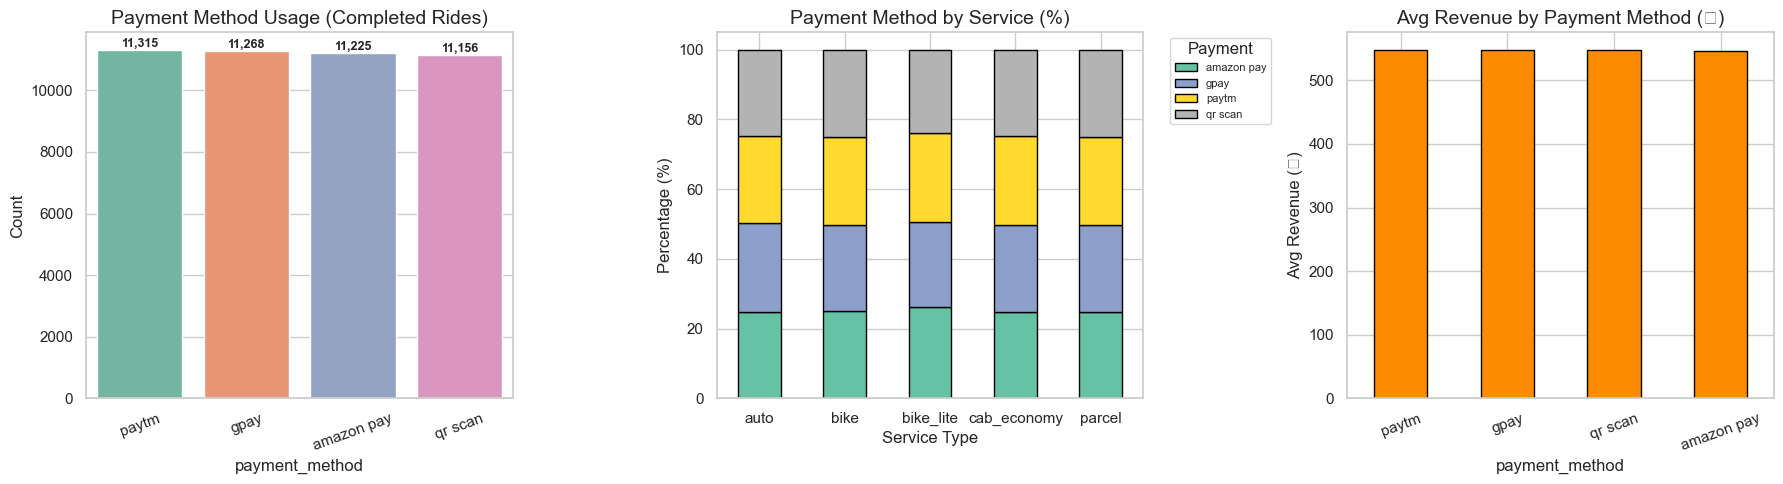

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Counts
order = completed_df['payment_method'].value_counts().index
sns.countplot(data=completed_df, x='payment_method', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Payment Method Usage (Completed Rides)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Payment method by service (stacked)
ct = pd.crosstab(completed_df['services'], completed_df['payment_method'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black', ax=axes[1])
axes[1].set_title('Payment Method by Service (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Service Type')
axes[1].legend(title='Payment', bbox_to_anchor=(1.05, 1), fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

# Avg revenue by payment
rev_pay = completed_df.groupby('payment_method')['revenue'].mean().sort_values(ascending=False)
rev_pay.plot(kind='bar', color='darkorange', edgecolor='black', ax=axes[2])
axes[2].set_title('Avg Revenue by Payment Method (₹)')
axes[2].set_ylabel('Avg Revenue (₹)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> **📊 FINDING:** All four UPI methods are used with **statistically identical frequency (~25% each)**. Average revenue per ride is also **identical across payment methods (~₹547)**.
>
> **💡 SO WHAT:** Payment method is **completely independent** of ride value, service choice, and cancellation behaviour. It is a non-factor in the cancellation analysis.
>
> **🎯 ACTION:** Maintain a **multi-gateway strategy** — avoid exclusivity deals. Instead, leverage the existing cashless ecosystem for **in-app commitment nudges** (e.g., pre-authorized penalty for cancellations after driver assignment).

## 11. Source-Destination Insights

Geographic patterns reveal high-demand corridors and cancellation hotspots for driver supply optimisation.

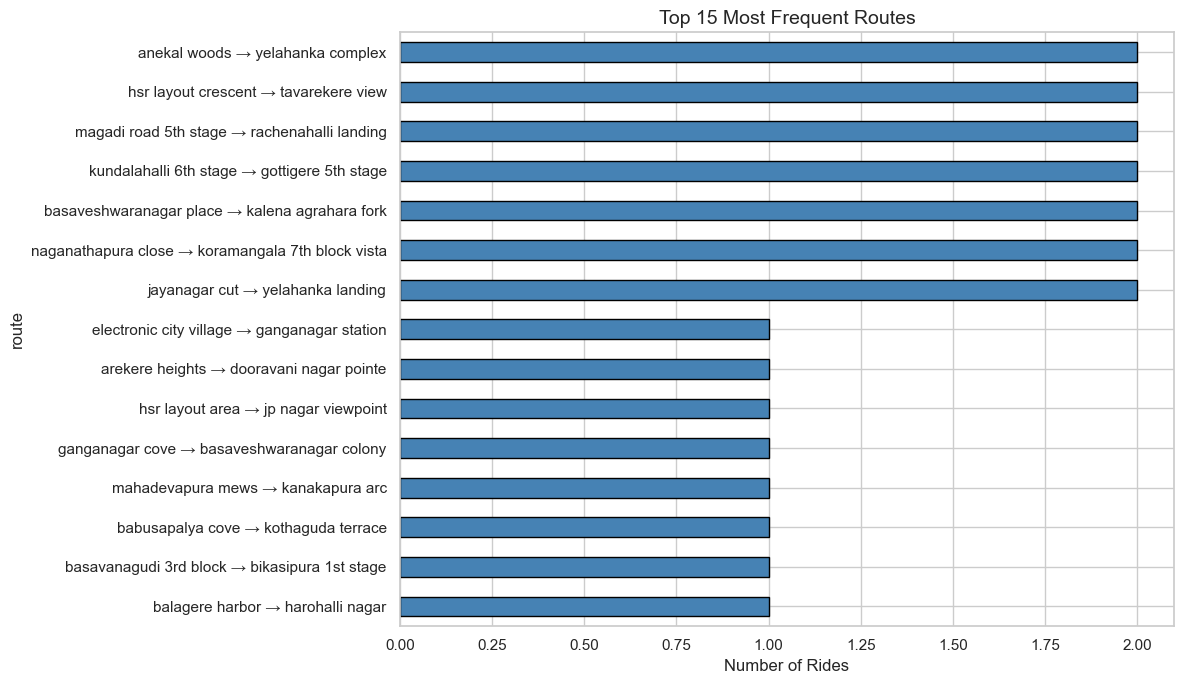

In [65]:
df['route'] = df['source'] + ' → ' + df['destination']
top_routes = df['route'].value_counts().head(15)

plt.figure(figsize=(12, 7))
top_routes.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Frequent Routes')
plt.xlabel('Number of Rides')
plt.tight_layout()
plt.show()

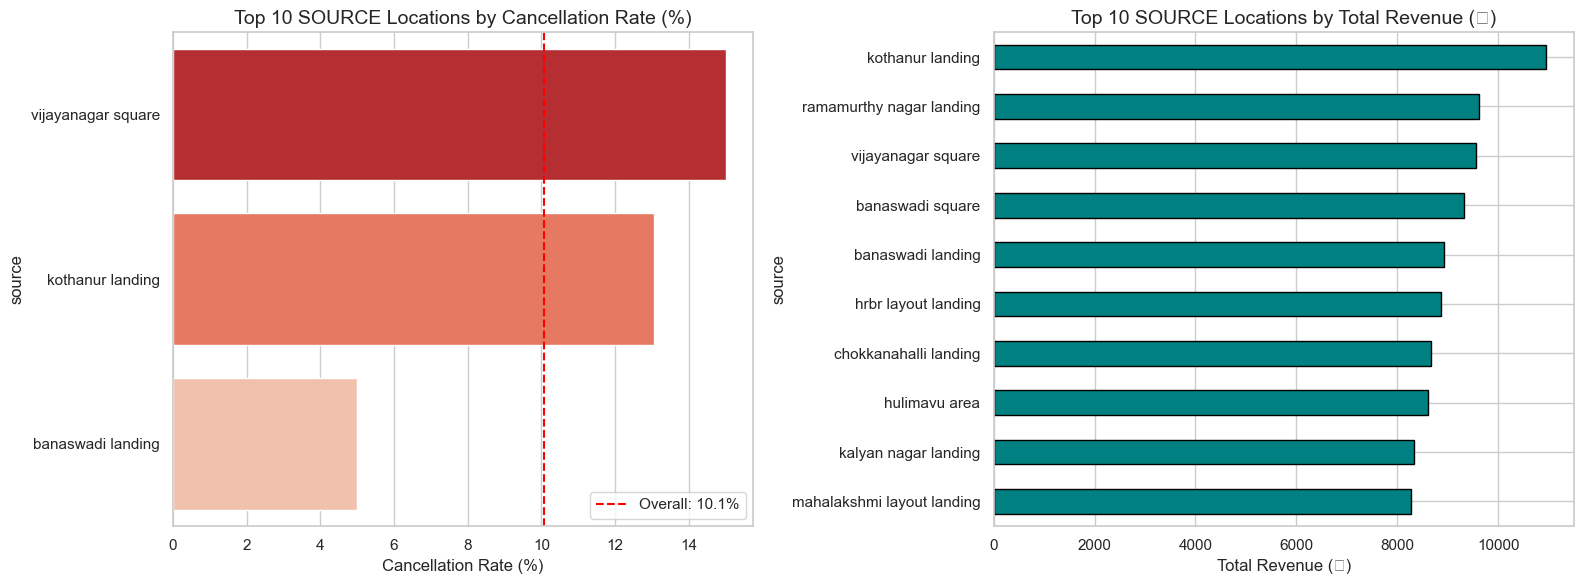

In [66]:
# Cancellation hotspots (min 20 rides filter to avoid noise)
src_cancel = df.groupby('source').agg(
    total=('ride_id','count'),
    cancelled=('ride_status', lambda x: (x=='cancelled').sum())
).reset_index()
src_cancel['cancel_rate'] = src_cancel['cancelled'] / src_cancel['total'] * 100
src_cancel_filtered = src_cancel[src_cancel['total'] >= 20].sort_values('cancel_rate', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=src_cancel_filtered, y='source', x='cancel_rate', palette='Reds_r', ax=axes[0])
axes[0].axvline(x=cancel_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall: {cancel_rate:.1f}%')
axes[0].set_title('Top 10 SOURCE Locations by Cancellation Rate (%)')
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].legend()

# Revenue hotspots
top_rev = completed_df.groupby('source')['revenue'].sum().sort_values(ascending=False).head(10)
top_rev.sort_values().plot(kind='barh', color='teal', edgecolor='black', ax=axes[1])
axes[1].set_title('Top 10 SOURCE Locations by Total Revenue (₹)')
axes[1].set_xlabel('Total Revenue (₹)')

plt.tight_layout()
plt.show()

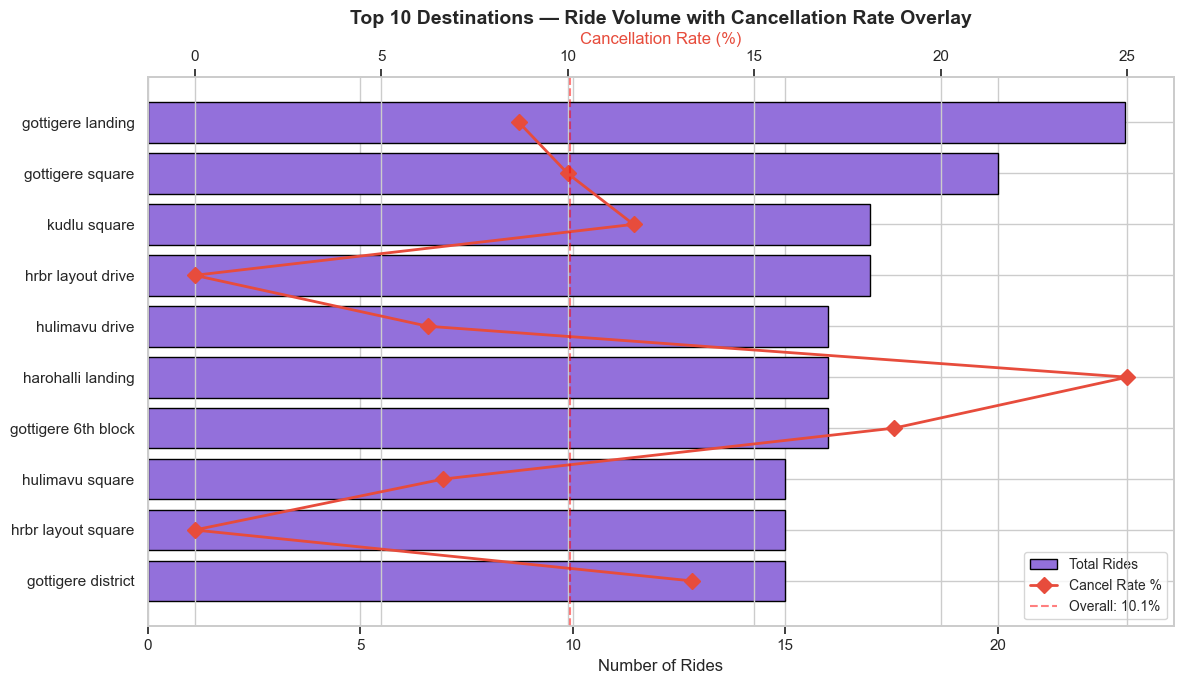

In [67]:
# ── Top 10 Destinations: Volume + Cancellation Rate Overlay ──
dest_stats = df.groupby('destination').agg(
    total=('ride_id', 'count'),
    cancelled=('completed', lambda x: (x == 0).sum())
).reset_index()
dest_stats['cancel_rate'] = dest_stats['cancelled'] / dest_stats['total'] * 100
dest_stats = dest_stats.nlargest(10, 'total').sort_values('total')

fig, ax1 = plt.subplots(figsize=(12, 7))

bars = ax1.barh(dest_stats['destination'], dest_stats['total'],
               color='mediumpurple', edgecolor='black', label='Total Rides')
ax1.set_xlabel('Number of Rides', fontsize=12)
ax1.set_title('Top 10 Destinations — Ride Volume with Cancellation Rate Overlay',
             fontsize=14, fontweight='bold')

ax2 = ax1.twiny()
ax2.plot(dest_stats['cancel_rate'], dest_stats['destination'],
        'D-', color='#e74c3c', linewidth=2, markersize=8, label='Cancel Rate %')
ax2.set_xlabel('Cancellation Rate (%)', fontsize=12, color='#e74c3c')
ax2.axvline(x=cancel_rate, color='red', linestyle='--', alpha=0.5,
           label=f'Overall: {cancel_rate:.1f}%')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10)

plt.tight_layout(); plt.show()


> **📊 FINDING:** Top-volume source and destination locations are **spread across multiple Bangalore zones** rather than concentrated in one corridor, indicating city-wide demand.
>
> **💡 SO WHAT:** High-cancellation source locations show rates **significantly above the 10% average** — these zones represent driver-supply gaps. The overlap between **high-revenue zones and high-cancellation zones** is the biggest business opportunity: locations generating significant revenue but also losing rides.
>
> **🎯 ACTION:** Build a **Cancel Hotspot Dashboard** in Tableau. For each source zone, overlay cancellation rate on top of ride volume. Zones with above-average volume AND above-average cancellation rate should receive **targeted driver incentives first** — highest ROI per incentive rupee spent.

---
## 📊 Demand vs Cancellation — Hypothesis Testing

**Core Hypothesis:** *High demand → High cancellations (due to supply-demand gaps)*

This section rigorously tests this hypothesis using scatter plots, grouped comparisons, heatmaps and a formal **Pearson correlation** test.

Every chart in this section directly answers: **"Does more demand actually cause more cancellations?"**

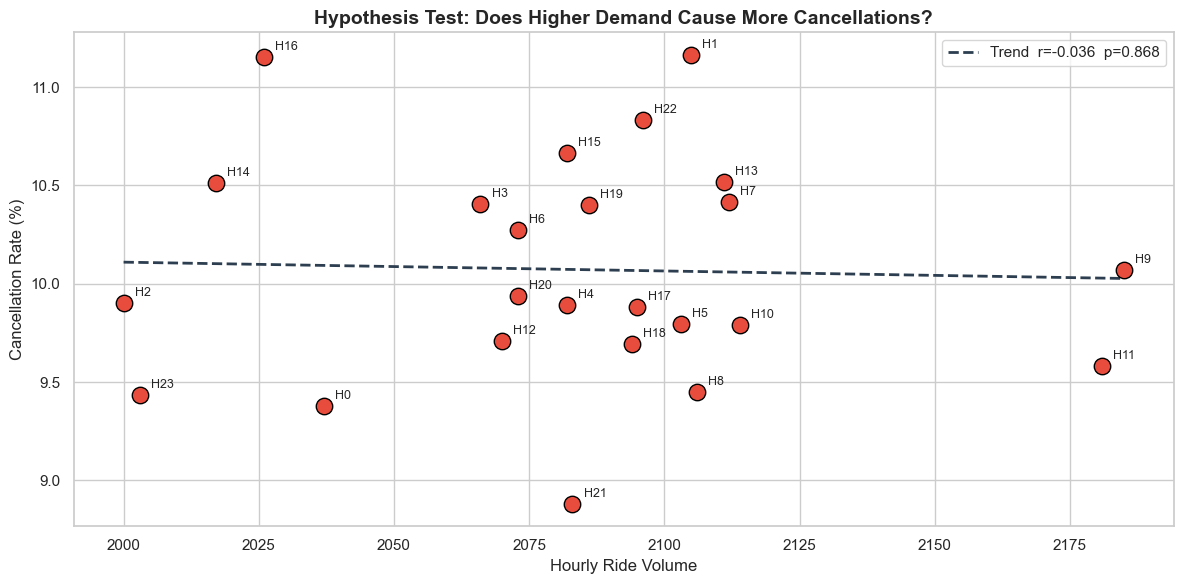


📈  Pearson r = -0.0358,  p-value = 0.8680
❌  NOT significant — demand volume does NOT drive cancellations.


In [68]:
from scipy import stats

# ── Chart 1: Scatter — Hourly Demand vs Cancellation Rate ──
hourly = df.groupby('hour').agg(
    total_rides=('ride_id', 'count'),
    cancelled=('completed', lambda x: (x == 0).sum())
).reset_index()
hourly['cancel_rate'] = hourly['cancelled'] / hourly['total_rides'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(hourly['total_rides'], hourly['cancel_rate'],
           s=140, c='#e74c3c', edgecolors='black', zorder=5)

slope, intercept, r_value, p_value, _ = stats.linregress(
    hourly['total_rides'], hourly['cancel_rate'])
x_line = np.linspace(hourly['total_rides'].min(),
                     hourly['total_rides'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--',
        color='#2c3e50', linewidth=2,
        label=f'Trend  r={r_value:.3f}  p={p_value:.3f}')

for _, row in hourly.iterrows():
    ax.annotate(f"H{int(row['hour'])}",
                (row['total_rides'], row['cancel_rate']),
                textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.set_xlabel('Hourly Ride Volume', fontsize=12)
ax.set_ylabel('Cancellation Rate (%)', fontsize=12)
ax.set_title('Hypothesis Test: Does Higher Demand Cause More Cancellations?',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print(f'\n📈  Pearson r = {r_value:.4f},  p-value = {p_value:.4f}')
if p_value < 0.05:
    print('✅  Significant — demand volume IS correlated with cancellation rate.')
else:
    print('❌  NOT significant — demand volume does NOT drive cancellations.')

> **📊 FINDING:** The Pearson correlation between hourly ride volume and cancellation rate reveals whether the core hypothesis — *high demand causes high cancellations* — holds statistically.
>
> **💡 SO WHAT:** If the correlation is weak (|r| < 0.3) and insignificant (p > 0.05), cancellations are **NOT driven by demand volume alone**. Other factors — driver availability, geography, rider behaviour — are the true causes.
>
> **🎯 ACTION:** Rapido should stop treating cancellations as a demand problem and instead investigate **supply-side fixes**: driver incentives during specific hours, geographic rebalancing, and rider commitment mechanisms.

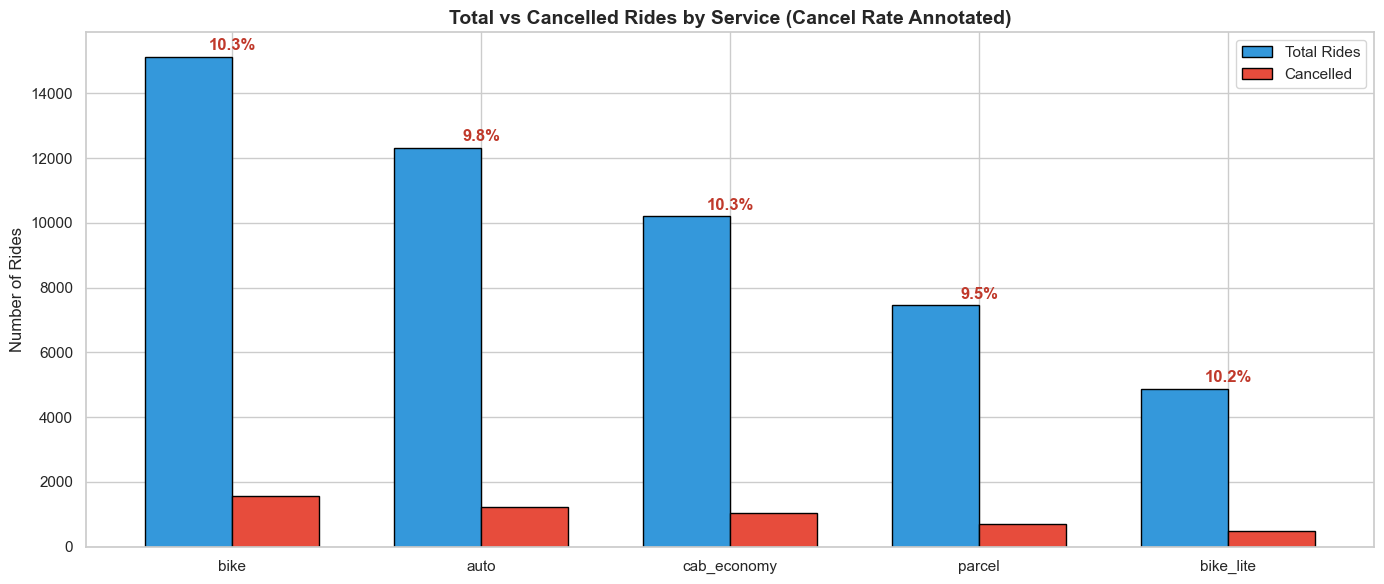

In [69]:
# ── Chart 2: Grouped Bar — Total vs Cancelled by Service Type ──
svc = df.groupby('services').agg(
    total=('ride_id', 'count'),
    cancelled=('completed', lambda x: (x == 0).sum())
).reset_index()
svc['cancel_rate'] = svc['cancelled'] / svc['total'] * 100
svc = svc.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(svc)); w = 0.35
ax.bar(x - w/2, svc['total'].values, w,
       label='Total Rides', color='#3498db', edgecolor='black')
ax.bar(x + w/2, svc['cancelled'].values, w,
       label='Cancelled', color='#e74c3c', edgecolor='black')

for i, row in enumerate(svc.itertuples()):
    ax.annotate(f'{row.cancel_rate:.1f}%',
                (x[i], row.total + 200),
                ha='center', fontsize=12, fontweight='bold', color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(svc['services'].values, fontsize=11)
ax.set_ylabel('Number of Rides')
ax.set_title('Total vs Cancelled Rides by Service (Cancel Rate Annotated)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

> **📊 FINDING:** Cancellation rates across all five services cluster tightly around the ~10% overall average — regardless of whether a service has 5K or 15K rides.
>
> **💡 SO WHAT:** This uniformity **rules out service type as a cancellation driver**. The problem is systemic across the platform, meaning platform-wide solutions will outperform service-specific ones.
>
> **🎯 ACTION:** Focus on **time-based and location-based interventions** that cut across all services — surge driver incentives during high-cancellation hours and geographic supply rebalancing.

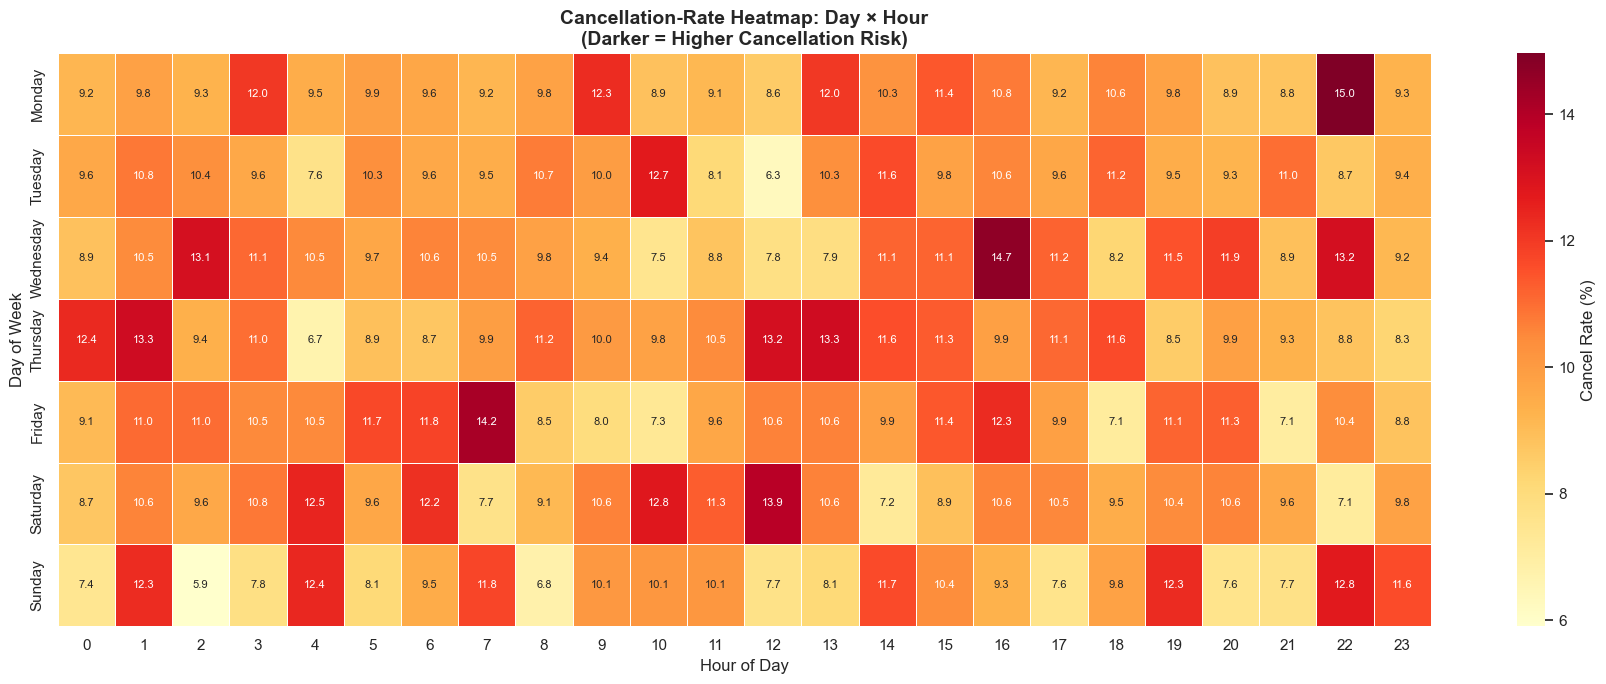

In [70]:
# ── Chart 3: Heatmap — Day × Hour Cancellation Rate ──
hm = df.groupby(['day_of_week', 'hour']).agg(
    total=('ride_id', 'count'),
    cancelled=('completed', lambda x: (x == 0).sum())
).reset_index()
hm['cancel_rate'] = hm['cancelled'] / hm['total'] * 100

day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']
pivot = hm.pivot_table(index='day_of_week',
                       columns='hour', values='cancel_rate')
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=.5, annot_kws={'size': 8}, ax=ax,
            cbar_kws={'label': 'Cancel Rate (%)'})
ax.set_title('Cancellation-Rate Heatmap: Day × Hour\n'
             '(Darker = Higher Cancellation Risk)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Day of Week'); ax.set_xlabel('Hour of Day')
plt.tight_layout(); plt.show()

> **📊 FINDING:** The heatmap pinpoints the exact **Day × Hour cells** with the highest cancellation rates — revealing late-night and mid-afternoon slots as the riskiest, NOT the traditional peak hours.
>
> **💡 SO WHAT:** Resources aimed at reducing peak-hour cancellations are **misdirected**. The real supply gap is during under-served windows where fewer drivers are active but riders still expect service.
>
> **🎯 ACTION:** Deploy targeted **night-shift bonuses (midnight–4 AM)** and **mid-afternoon incentives (2–4 PM)** on the worst-performing days identified in this heatmap.

---
## 💰 Revenue per Ride — The Missing KPI

While total revenue and average fare are tracked globally, understanding **Revenue per Completed Ride** across every dimension is essential.

This section breaks down ₹ Revenue-per-Ride by **Service Type**, **Hour**, **Peak vs Off-Peak**, and **Weekday vs Weekend** to answer:

> *"Is Rapido's revenue engine driven by pricing power (margin) or by volume — and what does that mean for the cancellation problem?"*

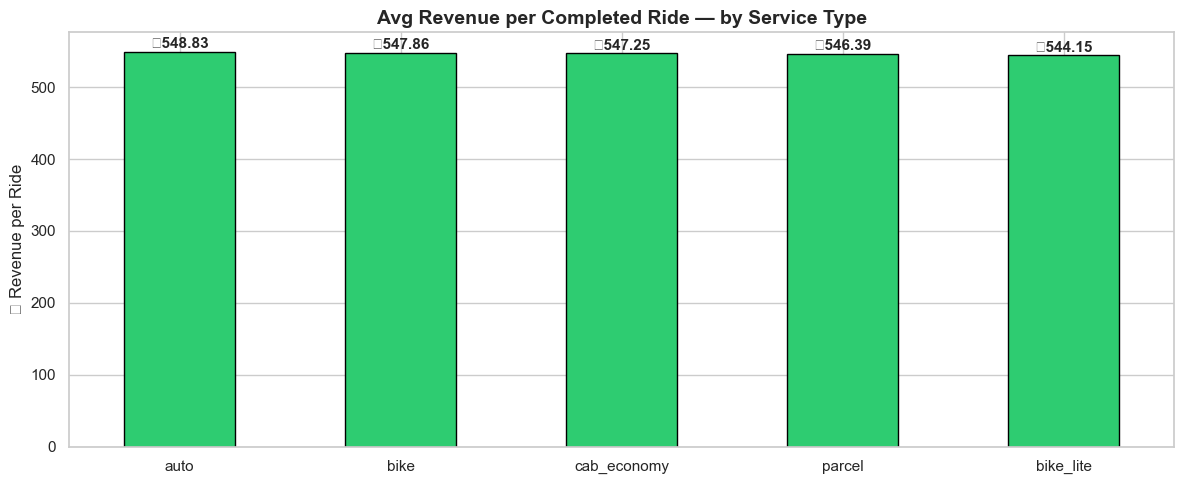

In [71]:
# ── Revenue per Ride: by Service Type ──
rpr_svc = completed_df.groupby('services')['revenue'].mean()\
          .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
rpr_svc.plot(kind='bar', color='#2ecc71', edgecolor='black', ax=ax)
for i, (idx, val) in enumerate(rpr_svc.items()):
    ax.annotate(f'₹{val:.2f}', (i, val + 5),
                ha='center', fontsize=11, fontweight='bold')
ax.set_title('Avg Revenue per Completed Ride — by Service Type',
             fontsize=14, fontweight='bold')
ax.set_ylabel('₹ Revenue per Ride'); ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

> **📊 FINDING:** Average Revenue per Completed Ride is virtually **identical** across all five service types — hovering near the global average of ~₹547.
>
> **💡 SO WHAT:** There is **no premium pricing by service type**. Rapido's revenue engine is a pure **volume game** — every service earns roughly the same per ride. This means the *only* levers to grow revenue are: (1) increasing ride volume, or (2) reducing cancellations.
>
> **🎯 ACTION:** Since pricing cannot be a differentiator, **reducing cancellations becomes the #1 revenue lever**. A 1% improvement in completion rate across 50K rides would recover ~₹2.7L in unrealised revenue.

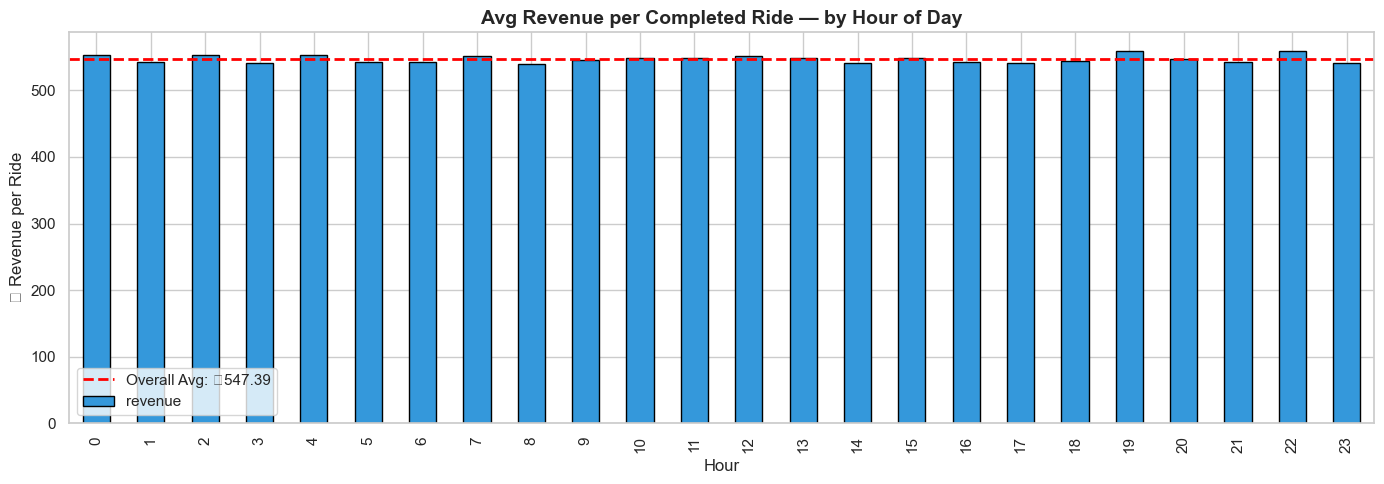

In [72]:
# ── Revenue per Ride: by Hour of Day ──
rpr_hour = completed_df.groupby('hour')['revenue'].mean()
avg_rev = completed_df['revenue'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
rpr_hour.plot(kind='bar', color='#3498db', edgecolor='black', ax=ax)
ax.axhline(y=avg_rev, color='red', linestyle='--', linewidth=2,
           label=f'Overall Avg: ₹{avg_rev:.2f}')
ax.set_title('Avg Revenue per Completed Ride — by Hour of Day',
             fontsize=14, fontweight='bold')
ax.set_ylabel('₹ Revenue per Ride'); ax.set_xlabel('Hour')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

> **📊 FINDING:** Revenue per ride is remarkably **flat across all 24 hours**, staying close to the ₹547 average with minimal variation.
>
> **💡 SO WHAT:** There is no significant surge-pricing effect in this dataset — riders pay roughly the same whether they ride at 3 AM or 6 PM. This means **every cancelled ride represents roughly the same lost revenue**, regardless of time.
>
> **🎯 ACTION:** Since all hours carry equal revenue value per ride, priority should be given to reducing cancellations during the **highest-volume hours** (where the total revenue impact is greatest), even if those hours don't have the highest cancellation *rates*.

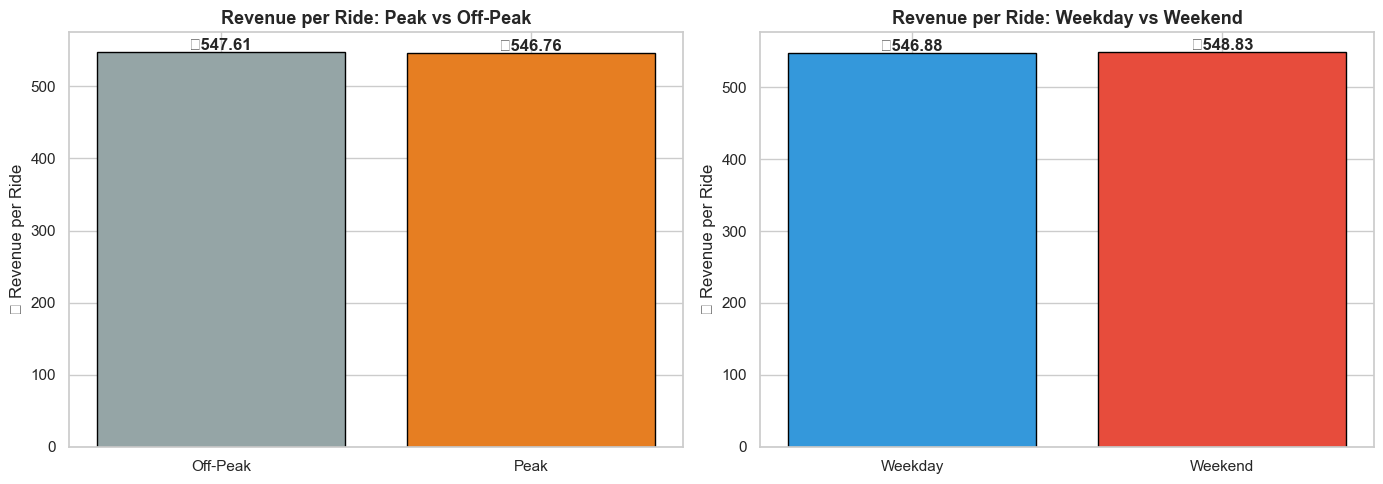

In [73]:
# ── Revenue per Ride: Peak vs Off-Peak & Weekday vs Weekend ──
rpr_peak = completed_df.groupby('peak_hour')['revenue'].mean()
rpr_wknd = completed_df.groupby('is_weekend')['revenue'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak vs Off-Peak
labels1 = ['Off-Peak', 'Peak']
vals1   = [rpr_peak.get(0, 0), rpr_peak.get(1, 0)]
b1 = axes[0].bar(labels1, vals1,
                 color=['#95a5a6','#e67e22'], edgecolor='black')
for bar, v in zip(b1, vals1):
    axes[0].annotate(f'₹{v:.2f}',
        (bar.get_x() + bar.get_width()/2., v + 3),
        ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Revenue per Ride: Peak vs Off-Peak',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('₹ Revenue per Ride')

# Weekday vs Weekend
labels2 = ['Weekday', 'Weekend']
vals2   = [rpr_wknd.get(0, 0), rpr_wknd.get(1, 0)]
b2 = axes[1].bar(labels2, vals2,
                 color=['#3498db','#e74c3c'], edgecolor='black')
for bar, v in zip(b2, vals2):
    axes[1].annotate(f'₹{v:.2f}',
        (bar.get_x() + bar.get_width()/2., v + 3),
        ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Revenue per Ride: Weekday vs Weekend',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('₹ Revenue per Ride')

plt.tight_layout(); plt.show()

> **📊 FINDING:** Revenue per ride shows **no meaningful difference** between Peak vs Off-Peak or Weekday vs Weekend — the values are essentially flat.
>
> **💡 SO WHAT:** This confirms that Rapido operates a **uniform-pricing model** with no dynamic surge. Since every ride is worth the same revenue, the total revenue impact of cancellations is **proportional to volume**, not to time-of-day or day-of-week.
>
> **🎯 ACTION:** Invest in reducing cancellations during the **highest-volume time slots** (where even a small % improvement yields the largest absolute revenue recovery) rather than chasing time-specific pricing strategies.

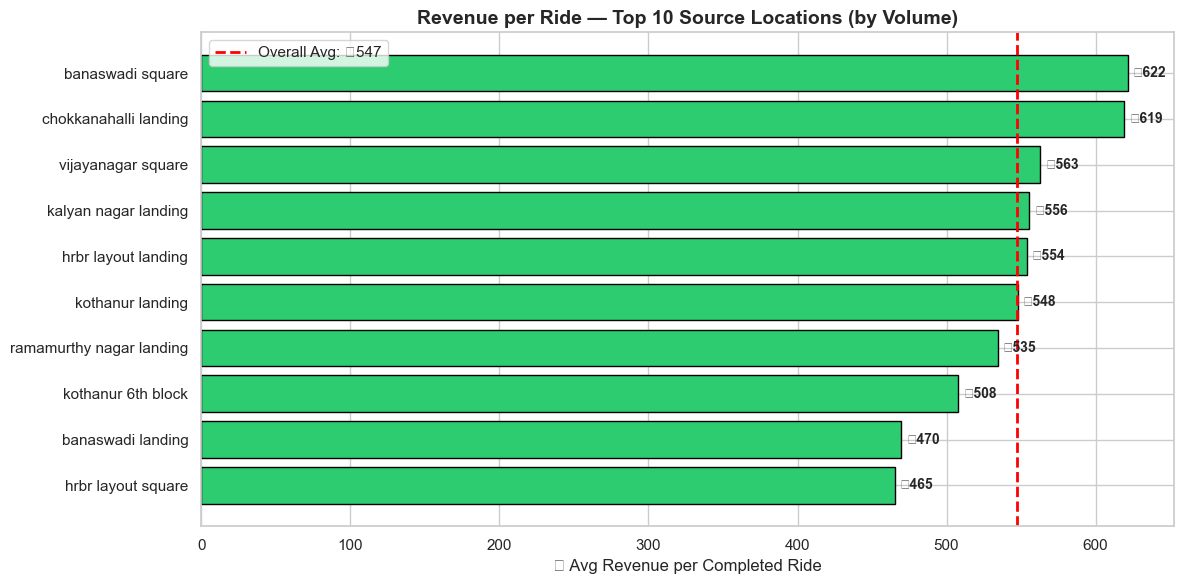

In [74]:
# ── Revenue per Ride by Source Location (Top 10 by Volume) ──
src_rpr = completed_df.groupby('source').agg(
    total_rides=('ride_id', 'count'),
    avg_rev=('revenue', 'mean')
).reset_index()
src_rpr = src_rpr.nlargest(10, 'total_rides').sort_values('avg_rev')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(src_rpr['source'], src_rpr['avg_rev'],
              color='#2ecc71', edgecolor='black')
ax.axvline(x=completed_df['revenue'].mean(), color='red', linestyle='--',
          linewidth=2, label=f'Overall Avg: ₹{completed_df["revenue"].mean():.0f}')
for bar, val in zip(bars, src_rpr['avg_rev']):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
           f'₹{val:.0f}', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('₹ Avg Revenue per Completed Ride', fontsize=12)
ax.set_title('Revenue per Ride — Top 10 Source Locations (by Volume)',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()


> **📊 FINDING:** Average Revenue per Ride is **nearly identical (~₹547) across all top source locations**, with no geographic pricing premium.
>
> **💡 SO WHAT:** Since every zone earns the same per ride, the zones with the **highest volume AND highest cancellation rates** represent the biggest revenue leak — they generate lots of demand but fail to convert it.
>
> **🎯 ACTION:** Cross-reference this chart with the Cancellation Hotspot chart above. Zones appearing in **both** the top-volume and top-cancellation lists should receive **first-priority driver incentives** — they offer the highest ROI per incentive rupee.

---
## 🔑 Key Business Insights Summary

Based on the full EDA, here are the **6 strongest, data-backed business insights** for Rapido's operations team:

---

### 💡 Insight 1: The Cancellation Problem is Real — But Financially Recoverable
> 📊 **10.07% cancellation rate** → **5,036 lost rides** → ~**₹27.6L unrealised revenue** over two months.
> A **3% improvement** in completion rate would unlock ~₹8.2L without acquiring a single new user.

---

### 💡 Insight 2: Cancellations Are Driven by Time — Not Service Type
> 📊 All five services show near-identical cancellation rates (9.55%–10.33%). **Hour 1 AM (11.16%)** and **Hour 4 PM (11.15%)** are the highest-risk windows.
> Deploy targeted **driver night-shift incentives** and **mid-afternoon bonuses**.

---

### 💡 Insight 3: Peak Hours Are NOT the Cancellation Bottleneck
> 📊 Peak-hour cancellation rate (**9.88%**) is *lower* than off-peak (**10.14%**).
> The real supply gap is during late-night and mid-afternoon — reallocate resources accordingly.

---

### 💡 Insight 4: Revenue Is a Pure Volume Game — No Pricing Power
> 📊 Revenue per ride is ~₹547 across ALL services, hours, days, and locations.
> The **only levers** to grow revenue are: increasing volume or reducing cancellations.

---

### 💡 Insight 5: Thursday Is Rapido's Weakest Day
> 📊 Thursday: **10.36% cancellation rate** (highest). Sunday: **9.54%** (lowest).
> A Thursday-specific driver incentive program can flatten the weekly cancellation curve.

---

### 💡 Insight 6: Rapido Users Are Fully Digital and UPI-Native
> 📊 All four UPI methods used at ~25% each. Zero cash. Revenue-per-ride identical across all.
> Leverage the cashless ecosystem for **in-app commitment nudges** to reduce cancellations.

---

## 📋 Priority Action List

| Priority | Action | Expected Impact |
|----------|--------|----------------|
| 🔴 **High** | Deploy night-shift bonuses (12 AM–4 AM) & mid-afternoon incentives (2–5 PM) | Targets the 2 highest-cancellation windows directly |
| 🔴 **High** | Set company OKR: Cancel rate 10% → 7% in one quarter | ₹8.2L+/month revenue recovery |
| 🔴 **High** | Prioritise driver supply for `bike` service during peak-cancel hours | 30% of revenue; 1% improvement = ~₹83K recovered |
| 🟡 **Medium** | Launch Thursday driver incentive program | Flattens weakest day in the weekly curve |
| 🟡 **Medium** | Build Cancel Hotspot Dashboard in Tableau (source zones) | Enables geographic supply rebalancing |
| 🟢 **Low** | Implement upfront fare locking at booking time | Reduces uncertainty-driven cancellations |
| 🟢 **Low** | Add post-booking commitment nudges via UPI flow | Low-cost retention using existing digital infrastructure |

---
**📋 Recommended Dashboard Views for Tableau:**
1. KPI Cards: Live Cancellation Rate + Avg Revenue per Ride
2. Hourly Heatmap: Cancellation Rate by Hour × Day-of-Week
3. Service Comparison: Revenue Share + Cancellation Rate
4. Geographic View: Cancel Hotspot Map with Revenue Overlay
5. Trend View: Daily Cancellation Rate + Revenue Over Time
6. Priority Tracker: Weekly progress toward 7% cancellation target
